# Multilingual mechanistic interpretability — full pipeline

One notebook for **SAE**, **JLens**, and **activation patching** on the same EN ↔ FA culture examples, with plots at every step.

| Part | What |
|------|------|
| **1** | Setup, model, shared culture item |
| 2 | SAE — train, L1 sweep, feature viz + autointerp |
| 3 | JLens — fit (last 7 layers), readouts, boards |
| 4 | Activation patching — ΔP curves, layer picks |
| 5 | Common example — all three on one item |
| 6 | Compare methods + export figures |

**Model default:** `google/gemma-2-9b` (override in `colab_setup.py`).  
**Data:** 200 Persian / Middle East culture MCQs (EN / FA / …).

## Part 1 — Setup and shared inputs

**Goal:** mount Drive (Colab), install the package, load config + model, and lock one bilingual question so Parts 2–6 stay aligned.

**Drive layout (Colab):**
```text
MyDrive/multilingual_mech/
  data/all200questions_persianMiddleEastCulture.json
  dist/*.whl
  notebooks/colab_setup.py
  output/   ← figures & exports land here

### Mount Google Drive (Colab only)
Required so we can reach `MyDrive/multilingual_mech/notebooks/colab_setup.py`.  
Skip this cell when running locally.

In [2]:
from pathlib import Path
try:
    import google.colab  # noqa: F401
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    print("Drive mounted:", Path("/content/drive/MyDrive").exists())
except ImportError:
    print("Not Colab — skip mount.")

Mounted at /content/drive
Drive mounted: True


In [3]:
from pathlib import Path
import runpy
def _resolve_setup_script() -> Path:
    here = Path.cwd()
    candidates = [
        here / "colab_setup.py",
        here / "notebooks" / "colab_setup.py",
        here.parent / "notebooks" / "colab_setup.py",
        Path("/content/drive/MyDrive/multilingual_mech/notebooks/colab_setup.py"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "colab_setup.py not found. Mount Drive and use folder multilingual_mech/, "
        "or open the notebook from the repo."
    )
_setup = runpy.run_path(str(_resolve_setup_script()))
globals().update({k: _setup[k] for k in _setup["EXPORTS"]})
# Session overrides (uncomment as needed):
# MODEL_NAME = "google/gemma-2-2b"
# USE_TINY_OFFLINE = True
import matplotlib.pyplot as plt
import torch
import pandas as pd
from multilingual_mechinterp.utils import ensure_dir, load_config
from multilingual_mechinterp.data import load_culture_questions, culture_prompt_pairs
from multilingual_mechinterp.metrics import evaluate_sae
from multilingual_mechinterp.sae import TiedSAE, sweep_l1, train_tied_sae
from multilingual_mechinterp.jlens import TinyDecoder, fit, run_jlens
from multilingual_mechinterp.patching import (
    TinyCausalLM,
    run_patching,
    recommend_layers,
)
cfg_path = CONFIG_DIR / "qwen25.yaml"
cfg = load_config(cfg_path) if cfg_path.exists() else {}
OUT = {
    "sae": ensure_dir(OUTPUT_DIR / "sae"),
    "jlens": ensure_dir(OUTPUT_DIR / "jlens"),
    "patching": ensure_dir(OUTPUT_DIR / "patching"),
    "comparison": ensure_dir(OUTPUT_DIR / "comparison"),
    "figures": ensure_dir(OUTPUT_DIR / "figures"),
}
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "font.size": 11})
print("Ready.")
print(" ROOT   =", ROOT)
print(" DATA   =", DATA_DIR)
print(" OUTPUT =", OUTPUT_DIR)
print(" MODEL  =", MODEL_NAME, "| tiny =", USE_TINY_OFFLINE)

[colab_setup] IN_COLAB=True
[colab_setup] ROOT=/content/drive/MyDrive/multilingual_mech
[colab_setup] OUTPUT_DIR=/content/drive/MyDrive/multilingual_mech/output
[colab_setup] MODEL_NAME=Qwen/Qwen2.5-1.5B  USE_TINY_OFFLINE=False
[colab_setup] Installing 1 wheel(s) from /content/drive/MyDrive/multilingual_mech/dist
[colab_setup] culture data OK: /content/drive/MyDrive/multilingual_mech/data/all200questions_persianMiddleEastCulture.json
Ready.
 ROOT   = /content/drive/MyDrive/multilingual_mech
 DATA   = /content/drive/MyDrive/multilingual_mech/data
 OUTPUT = /content/drive/MyDrive/multilingual_mech/output
 MODEL  = Qwen/Qwen2.5-1.5B | tiny = False


### Load experiment model

Uses `MODEL_NAME` from `colab_setup.py` (default **Qwen2.5-1.5B**).

- `USE_TINY_OFFLINE=True` → tiny stand-ins (fast, no HF download)
- otherwise → `load_experiment_model()` (GPU recommended on Colab)

In [4]:
import os
from multilingual_mechinterp.models.loader import LoadedModel

# HF token (same as Cell 5)
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    pass
HF_TOKEN = HF_TOKEN or os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

# Force real model (not tiny offline)
USE_TINY_OFFLINE = False

if HF_TOKEN:
    model = load_experiment_model(token=HF_TOKEN)
else:
    model = load_experiment_model()

print(type(model), getattr(model, "name", None), getattr(model, "n_layers", None))
assert isinstance(model, LoadedModel), "Expected LoadedModel from load_experiment_model()"

[colab_setup] Loading model: Qwen/Qwen2.5-1.5B


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

<class 'multilingual_mechinterp.models.loader.LoadedModel'> Qwen/Qwen2.5-1.5B 28


### Shared culture item (EN ↔ FA)

Load the 200-question culture set and lock **one** parallel pair.  
Later parts reuse `PROMPT_EN`, `PROMPT_FA`, and `ANSWER`.

n_questions=200  item_id=1  ITEM_IDX=0
--- EN ---
Which poetic collection by Hafez is traditionally used in Iran for fal-e Hafez?

A. Divan-e Saadi
B. Bustan-e Hafez
C. Divan-e Hafez
D. Golestan-e Saadi

Answer:
--- FA ---
کدام مجموعه شعری حافظ به‌طور سنتی در ایران برای فال حافظ استفاده می‌شود؟

A. دیوان سعدی
B. بوستان حافظ
C. دیوان حافظ
D. گلستان سعدی

Answer:
--- answer EN --- Divan-e Hafez
--- answer FA --- دیوان حافظ


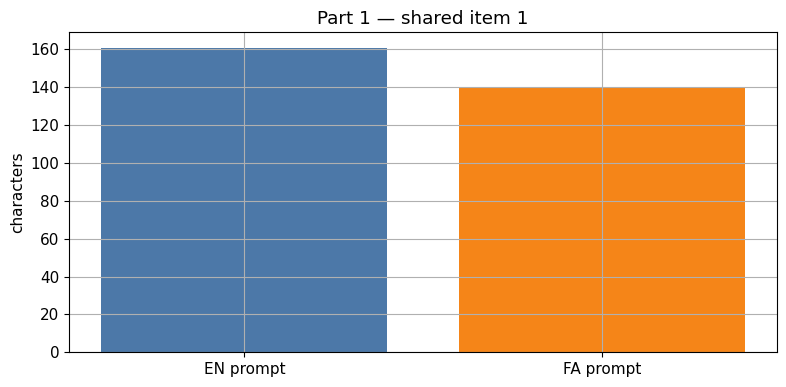

In [5]:
path = culture_json_path()
ITEM_IDX = 0  # change to try another question

if path.exists():
    qs = load_culture_questions(path)
    pairs = culture_prompt_pairs(
        qs,
        source_lang="english",
        target_lang="persian",
        limit=max(ITEM_IDX + 1, 5),
    )
    pair = pairs[ITEM_IDX]
else:
    qs = []
    pair = {
        "id": "demo",
        "source_prompt": "The capital of France is",
        "target_prompt": "پایتخت فرانسه",
        "source_answer": "Paris",
        "target_answer": "پاریس",
    }
    print("WARNING: culture JSON missing — using demo pair.")

PROMPT_EN = pair["source_prompt"]
PROMPT_FA = pair["target_prompt"]
ANSWER = pair["source_answer"]
ANSWER_FA = pair.get("target_answer", "")
# MCQ correct option letter (A–D) — use this for baseline / JLens / patching metrics
CORRECT_INDEX = int(pair.get("correct_index", 0))
CORRECT_LETTER = str(pair.get("correct_letter") or chr(ord("A") + CORRECT_INDEX))

print(f"n_questions={len(qs)}  item_id={pair.get('id')}  ITEM_IDX={ITEM_IDX}")
print(f"correct_letter={CORRECT_LETTER!r}  (index={CORRECT_INDEX})  gold EN={ANSWER!r}")
print("--- EN ---")
print(PROMPT_EN[:500])
print("--- FA ---")
print(PROMPT_FA[:500])
print("--- answer EN ---", ANSWER)
print("--- answer FA ---", ANSWER_FA)

fig, ax = plt.subplots()
ax.bar(["EN prompt", "FA prompt"], [len(PROMPT_EN), len(PROMPT_FA)], color=["#4C78A8", "#F58518"])
ax.set_ylabel("characters")
ax.set_title(f"Part 1 — shared item {pair.get('id')}")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part1_prompt_lengths.png", dpi=150)
plt.show()

## Part 1.5 — Behavioural baseline (MCQ option letters)

Before SAE / JLens / patching: what does the model **actually predict** for the matched EN/FA prompts?

Score next-token probs over **A/B/C/D** (not the answer text). Metric:

$$M = L_{\text{correct}} - \max(L_{\text{wrong}})$$


In [ ]:
from multilingual_mechinterp.data import score_mcq_prompt
from multilingual_mechinterp.utils import save_json

baseline_en = score_mcq_prompt(model, PROMPT_EN, correct_letter=CORRECT_LETTER, device=str(model.device))
baseline_fa = score_mcq_prompt(model, PROMPT_FA, correct_letter=CORRECT_LETTER, device=str(model.device))

print(f"Correct option letter = {CORRECT_LETTER}")
print("--- EN ---")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in baseline_en.items() if k != "option_ids"})
print("--- FA ---")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in baseline_fa.items() if k != "option_ids"})

letters = list("ABCD")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, bl, title in [(axes[0], baseline_en, "EN"), (axes[1], baseline_fa, "FA")]:
    ax.bar(letters, [bl["probs"][L] for L in letters], color="#4C78A8" if title == "EN" else "#F58518")
    ax.axvline(letters.index(CORRECT_LETTER), color="k", ls="--", alpha=0.5, label=f"gold {CORRECT_LETTER}")
    ax.set_title(f"{title}: pred={bl['pred_letter']}  P(gold)={bl['p_correct']:.3f}  margin={bl['margin']:.2f}")
    ax.set_ylabel("P(option)")
    ax.legend(fontsize=8)
plt.suptitle(f"Behavioural baseline — item {pair.get('id')}")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part1_5_baseline_mcq.png", dpi=150)
plt.show()

baseline_summary = {
    "item_id": pair.get("id"),
    "correct_letter": CORRECT_LETTER,
    "en": {k: baseline_en[k] for k in ("probs", "p_correct", "margin", "pred_letter", "correct")},
    "fa": {k: baseline_fa[k] for k in ("probs", "p_correct", "margin", "pred_letter", "correct")},
}
save_json(baseline_summary, OUT["comparison"] / "baseline_mcq.json")
print("Wrote", OUT["comparison"] / "baseline_mcq.json")



## Part 2 — Sparse Autoencoders (on the loaded model)

Extract **residual activations** from `MODEL_NAME` on culture prompts (EN + FA), train a tied SAE, sweep L1 (α), and plot FVU / L0 / top features.

Paper: [arXiv:2309.08600](https://arxiv.org/abs/2309.08600)

### 2.1 Extract residual activations from the model

In [27]:
from multilingual_mechinterp.models.loader import LoadedModel
from multilingual_mechinterp.sae import extract_residual_activations

# Must be the real HF wrapper from Cell 5
if not isinstance(model, LoadedModel):
    raise TypeError(
        "model is not a LoadedModel. In Cell 5 set USE_TINY_OFFLINE=False "
        "and run model = load_experiment_model()."
    )

sae_cfg = cfg.get(
    "sae",
    {
        "ratio": 2,
        "alpha": 8.6e-4,
        "lr": 1e-3,
        "alphas": [1e-4, 3e-4, 8.6e-4, 1.4e-3, 3e-3],
        "batch_size": 512,
        "n_epochs": 1,
    },
)

# Layer: mid-depth if config says null
SAE_LAYER = sae_cfg.get("layer")
if SAE_LAYER is None:
    SAE_LAYER = max(1, model.n_layers // 2)

# Texts: shared item + a few more culture pairs (EN + FA)
N_PAIR = 100  # raise for stronger SAE (slower)
path = culture_json_path()
qs_all = load_culture_questions(path)
pairs_more = culture_prompt_pairs(
    qs_all, source_lang="english", target_lang="persian", limit=N_PAIR
)
texts = []
for p in pairs_more:
    texts.append(p["source_prompt"])
    texts.append(p["target_prompt"])
# ensure Part 1 item is included
texts = list(dict.fromkeys([PROMPT_EN, PROMPT_FA, *texts]))

device = "cuda" if torch.cuda.is_available() else str(model.device)
print(f"model={model.name}  n_layers={model.n_layers}  SAE_LAYER={SAE_LAYER}  n_texts={len(texts)}  device={device}")

acts = extract_residual_activations(
    model,
    texts,
    layer=SAE_LAYER,
    max_length=256,
    batch_size=2 if device == "cuda" else 1,
    device=device,
)
print("acts shape:", tuple(acts.shape))  # [n_tokens, d_model]

# Heavy residual dump — keep False for figures/numbers-only exports.
SAVE_ACTS = False
if SAVE_ACTS:
    torch.save(acts, OUT["sae"] / f"acts_L{SAE_LAYER}.pt")
    print("saved:", OUT["sae"] / f"acts_L{SAE_LAYER}.pt")
else:
    print("SKIPPED acts_*.pt (figures/numbers workflow)")

model=Qwen/Qwen2.5-1.5B  n_layers=28  SAE_LAYER=14  n_texts=200  device=cuda


extract L14: 100%|██████████| 100/100 [00:04<00:00, 23.78it/s]


acts shape: (12291, 1536)
saved: /content/drive/MyDrive/multilingual_mech/output/sae/acts_L14.pt


### 2.2 Train one tied SAE

torch.cuda.is_available() = True
training device = cuda
GPU = NVIDIA A100-SXM4-40GB


train epoch 2/2: 100%|██████████| 49/49 [00:00<00:00, 286.17it/s]


{'fvu': 0.00211887015029788, 'r_squared': 0.9978811298497021, 'mean_l0': 840.082763671875, 'n_active_features_mean': 840.082763671875, 'dead_features': 818, 'dead_fraction': 0.2662760416666667, 'n_feats': 3072}


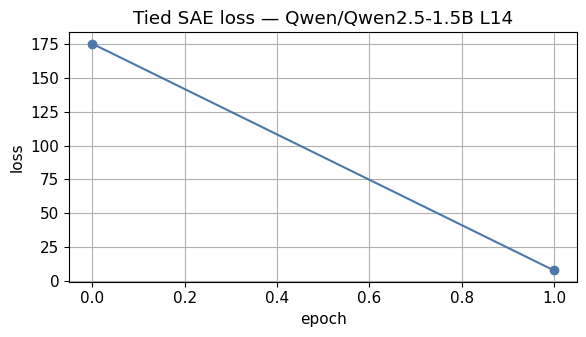

In [28]:
train_device = "cuda" if torch.cuda.is_available() else "cpu"

# keep a CPU copy for saving / later CPU eval
acts_cpu = acts.detach().float().cpu()
train_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch.cuda.is_available() = {torch.cuda.is_available()}")
print(f"training device = {train_device}")
if train_device == "cuda":
    print(f"GPU = {torch.cuda.get_device_name(0)}")
single = train_tied_sae(
    acts_cpu,
    ratio=sae_cfg["ratio"],
    alpha=sae_cfg["alpha"],
    lr=sae_cfg["lr"],
    batch_size=min(256, max(32, acts_cpu.shape[0] // 4)),
    n_epochs=int(sae_cfg.get("n_epochs", 1)) + 1,
    device=train_device,
)

# IMPORTANT: eval batch must match SAE device
eval_n = min(4000, acts_cpu.shape[0])
eval_batch = acts_cpu[:eval_n].to(train_device)
sae_metrics = evaluate_sae(single.sae, eval_batch)
print(sae_metrics)

# optional: move SAE back to CPU for later cells
single.sae.to("cpu")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot([h["loss"] for h in single.history], marker="o", color="#4C78A8")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title(f"Tied SAE loss — {model.name} L{SAE_LAYER}")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part2_sae_train_loss.png", dpi=150)
plt.show()

### 2.3 L1 (α) sweep — FVU vs sparsity

train epoch 1/1: 100%|██████████| 49/49 [00:00<00:00, 269.88it/s]


alpha=1.00e-04  FVU=0.0095  mean_l0=1081.15  dead=511  -> /content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_1.00e-04.pt


train epoch 1/1: 100%|██████████| 49/49 [00:00<00:00, 271.19it/s]


alpha=3.00e-04  FVU=0.0082  mean_l0=1030.45  dead=607  -> /content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_3.00e-04.pt


train epoch 1/1: 100%|██████████| 49/49 [00:00<00:00, 288.57it/s]


alpha=8.60e-04  FVU=0.0101  mean_l0=922.21  dead=806  -> /content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_8.60e-04.pt


train epoch 1/1: 100%|██████████| 49/49 [00:00<00:00, 282.73it/s]


alpha=1.40e-03  FVU=0.0131  mean_l0=851.51  dead=965  -> /content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_1.40e-03.pt


train epoch 1/1: 100%|██████████| 49/49 [00:00<00:00, 286.58it/s]


alpha=3.00e-03  FVU=0.0162  mean_l0=742.62  dead=1254  -> /content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_3.00e-03.pt


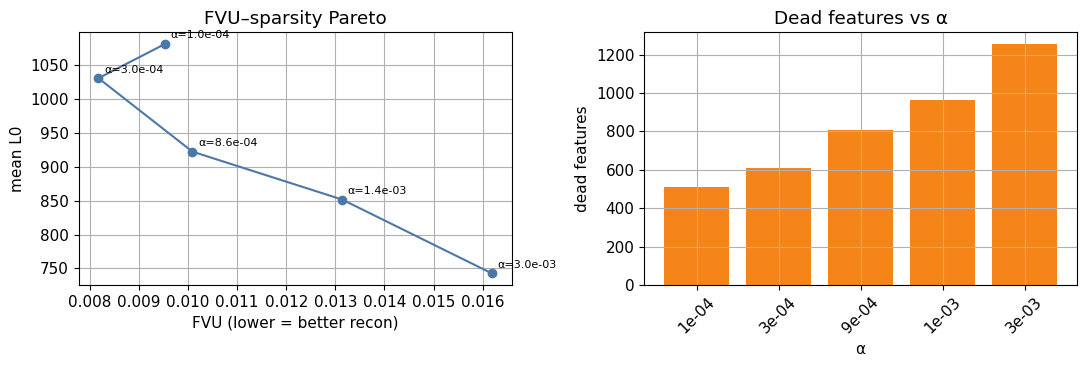

[{'alpha': 0.0001,
  'checkpoint': '/content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_1.00e-04.pt',
  'fvu': 0.009537111036479473,
  'r_squared': 0.9904628889635205,
  'mean_l0': 1081.1544189453125,
  'n_active_features_mean': 1081.1544189453125,
  'dead_features': 511,
  'dead_fraction': 0.16634114583333334,
  'n_feats': 3072,
  'final_loss': 167.84277362847814},
 {'alpha': 0.0003,
  'checkpoint': '/content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_3.00e-04.pt',
  'fvu': 0.008176425471901894,
  'r_squared': 0.9918235745280981,
  'mean_l0': 1030.4461669921875,
  'n_active_features_mean': 1030.4461669921875,
  'dead_features': 607,
  'dead_fraction': 0.19759114583333334,
  'n_feats': 3072,
  'final_loss': 169.83950267762555},
 {'alpha': 0.00086,
  'checkpoint': '/content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_8.60e-04.pt',
  'fvu': 0.010089032351970673,
  'r_squared': 0.9899109676480293,
  'mean_l0': 922.2089

In [29]:
alphas = sae_cfg.get("alphas", [1e-4, 3e-4, 8.6e-4, 1.4e-3, 3e-3])
# Checkpoints are large (~200MB each on 9B). False = sweep_metrics.json only.
# Later cells use in-memory `sae` from §2.2 if checkpoints are off — no kernel restart.
SAVE_SAE_CHECKPOINTS = False
rows = sweep_l1(
    acts,
    alphas=alphas,
    ratio=sae_cfg["ratio"],
    output_dir=OUT["sae"] / "l1_sweep",
    lr=sae_cfg["lr"],
    batch_size=min(256, max(32, acts.shape[0] // 4)),
    n_epochs=1,
    device=train_device,
    save_checkpoints=SAVE_SAE_CHECKPOINTS,
    save_learned_dicts=False,
)

fvu = [r["fvu"] for r in rows]
l0 = [r["mean_l0"] for r in rows]
dead = [r["dead_features"] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(fvu, l0, marker="o", color="#4C78A8")
for r, x, y in zip(rows, fvu, l0):
    axes[0].annotate(f"α={r['alpha']:.1e}", (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0].set_xlabel("FVU (lower = better recon)")
axes[0].set_ylabel("mean L0")
axes[0].set_title("FVU–sparsity Pareto")

axes[1].bar([f"{r['alpha']:.0e}" for r in rows], dead, color="#F58518")
axes[1].set_xlabel("α")
axes[1].set_ylabel("dead features")
axes[1].set_title("Dead features vs α")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(OUT["figures"] / "part2_fvu_l0_pareto.png", dpi=150)
plt.show()
rows

### 2.4 Top features on real activations

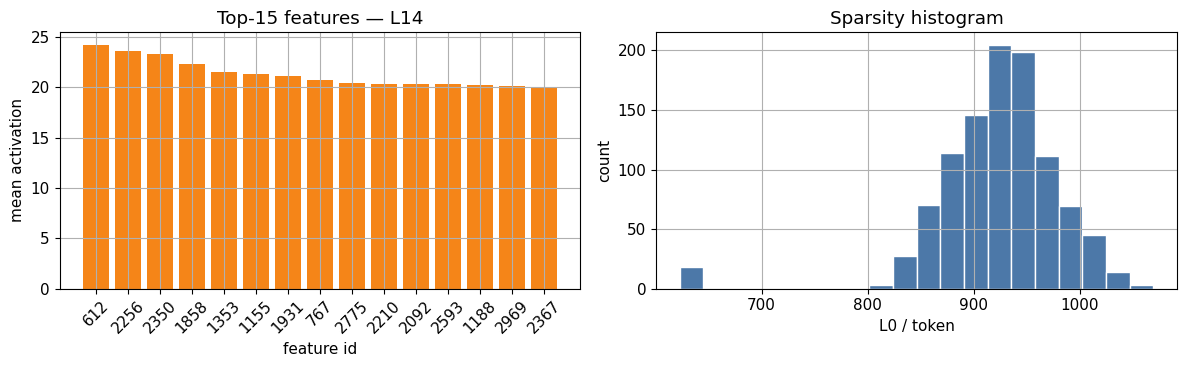

mid α = 0.00086
checkpoint = /content/drive/MyDrive/multilingual_mech/output/sae/l1_sweep/tied_sae_alpha_8.60e-04.pt
device = cpu


In [30]:
mid = rows[len(rows) // 2]
sae = TiedSAE.load(mid["checkpoint"], device="cpu")

acts_cpu = acts.detach().float().cpu()
x = acts_cpu[: min(1024, acts_cpu.shape[0])]

with torch.no_grad():
    codes = sae.encode(x)

mean_act = codes.mean(0)
topk = torch.topk(mean_act, k=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(
    [str(int(i)) for i in topk.indices],
    topk.values.numpy(),
    color="#F58518",
)
axes[0].set_xlabel("feature id")
axes[0].set_ylabel("mean activation")
axes[0].set_title(f"Top-15 features — L{SAE_LAYER}")
axes[0].tick_params(axis="x", rotation=45)

l0_per = (codes > 0).float().sum(-1).numpy()
axes[1].hist(l0_per, bins=20, color="#4C78A8", edgecolor="white")
axes[1].set_xlabel("L0 / token")
axes[1].set_ylabel("count")
axes[1].set_title("Sparsity histogram")

plt.tight_layout()
fig.savefig(OUT["figures"] / "part2_top_features.png", dpi=150)
plt.show()

print("mid α =", mid["alpha"])
print("checkpoint =", mid["checkpoint"])
print("device =", next(sae.parameters()).device)

### 2.5 SAE autointerpretability (max-activating contexts + LLM label)

Phase 1 needs at least one **interpreted** feature (§3.5). Workflow:

1. For each top feature id, find token windows where \(c_k\) is highest.
2. Inspect shared patterns (manual).
3. Optionally ask a **separate, stronger instruct model** to propose a short label (autointerp).

**Interpreter model:** do **not** use Gemma-2-9B as both subject and labeler. Prefer a strong chat model
(`gpt-4o`, Claude, or a strong open instruct). Set `AUTOINTERP_BACKEND` below.


In [ ]:
# --- Max-activating contexts for top SAE features ---
from collections import defaultdict
from multilingual_mechinterp.utils import save_json

N_AUTO_FEATURES = 5          # interpret this many top features
N_SNIPPETS = 8               # max-activating windows per feature
WINDOW = 8                   # tokens left/right of peak
AUTOINTERP_BACKEND = "manual"  # "manual" | "openai" | "hf"
# Separate *strong* instruct model — NOT the experiment LLM (Gemma 9B).
AUTOINTERP_MODEL = "gpt-4o-mini"  # or "meta-llama/Meta-Llama-3.1-8B-Instruct", etc.

assert "sae" in dir() and "texts" in dir() and "topk" in dir()

feat_ids = [int(i) for i in topk.indices[:N_AUTO_FEATURES].tolist()]
tok = model.tokenizer
device_ai = "cuda" if torch.cuda.is_available() else "cpu"
sae_ai = sae.to(device_ai)

# Score each text: max c_k and local window around the peak token
records = {fid: [] for fid in feat_ids}

for text in texts[: min(80, len(texts))]:
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad(), __import__("multilingual_mechinterp.models.hooks", fromlist=["hooked_forward"]).hooked_forward(
        model.model, layers=[SAE_LAYER]
    ) as cache:
        model.model(**enc)
        acts_t = cache.get(f"blocks.{SAE_LAYER}")[0]  # [T, d]
    mask = enc["attention_mask"][0].bool()
    acts_t = acts_t[mask].float()
    ids = enc["input_ids"][0][mask]
    with torch.no_grad():
        codes_t = sae_ai.encode(acts_t.to(device_ai)).cpu()  # [T, d_sae]
    for fid in feat_ids:
        col = codes_t[:, fid]
        peak = int(col.argmax())
        score = float(col[peak])
        lo, hi = max(0, peak - WINDOW), min(len(ids), peak + WINDOW + 1)
        window_ids = ids[lo:hi].tolist()
        snippet = tok.decode(window_ids)
        peak_tok = tok.decode([int(ids[peak])])
        records[fid].append({"score": score, "peak_token": peak_tok, "snippet": snippet, "text_preview": text[:160]})

# keep top snippets per feature
autointerp = []
for fid in feat_ids:
    best = sorted(records[fid], key=lambda r: -r["score"])[:N_SNIPPETS]
    entry = {"feature_id": fid, "mean_activation": float(mean_act[fid]), "top_snippets": best, "proposed_label": None}
    autointerp.append(entry)
    print(f"\n=== feature {fid} (mean_act={entry['mean_activation']:.3f}) ===")
    for s in best[:5]:
        print(f"  [{s['score']:.2f}] peak={s['peak_token']!r} | {s['snippet'][:120]!r}")

# Optional LLM labeling
if AUTOINTERP_BACKEND == "openai":
    import os, json as _json
    try:
        from openai import OpenAI
        client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
        for entry in autointerp:
            snippets = "\n".join(f"- {s['snippet']}" for s in entry["top_snippets"][:6])
            prompt = (
                "You label sparse autoencoder features from max-activating text snippets.\n"
                "Give a short (≤8 word) concept label and one sentence of evidence.\n"
                f"Feature id {entry['feature_id']}:\n{snippets}\n"
                'Reply JSON: {"label": "...", "rationale": "..."}'
            )
            resp = client.chat.completions.create(
                model=AUTOINTERP_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.2,
            )
            raw = resp.choices[0].message.content or ""
            try:
                parsed = _json.loads(raw[raw.find("{") : raw.rfind("}") + 1])
            except Exception:
                parsed = {"label": raw[:80], "rationale": ""}
            entry["proposed_label"] = parsed.get("label")
            entry["rationale"] = parsed.get("rationale")
            print(f"LLM label f{entry['feature_id']}: {entry['proposed_label']}")
    except Exception as exc:
        print("OpenAI autointerp failed:", exc, "— keeping manual snippets only")
elif AUTOINTERP_BACKEND == "hf":
    print("HF backend: set AUTOINTERP_BACKEND='openai' or label snippets manually for Phase 1.")
else:
    print("\nManual mode: assign informal labels from snippets above (Phase 1 §3.5).")

out_ai = OUT["sae"] / "autointerp_top_features.json"
save_json(autointerp, out_ai)
print("Wrote", out_ai)



### 2.6 Shared-pair SAE: EN vs FA feature contrast

Not global top features — activations for **this** EN prompt vs **this** FA prompt at `SAE_LAYER`.


In [ ]:
# EN vs FA SAE codes for the shared culture pair
from multilingual_mechinterp.models.hooks import hooked_forward

assert "sae" in dir() or "rows" in dir()
_sae = sae if "sae" in dir() else TiedSAE.load(rows[len(rows) // 2]["checkpoint"], device="cpu")
_sae = _sae.to("cpu")

def _prompt_codes(prompt: str):
    enc = model.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad(), hooked_forward(model.model, layers=[SAE_LAYER]) as cache:
        model.model(**enc)
        acts_t = cache.get(f"blocks.{SAE_LAYER}")[0]
    mask = enc["attention_mask"][0].bool()
    acts_t = acts_t[mask].float().cpu()
    with torch.no_grad():
        return _sae.encode(acts_t)  # [T, d_sae]

codes_en = _prompt_codes(PROMPT_EN)
codes_fa = _prompt_codes(PROMPT_FA)
mean_en, mean_fa = codes_en.mean(0), codes_fa.mean(0)
diff = (mean_en - mean_fa).abs()
top_diff = torch.topk(diff, k=12)

fig, ax = plt.subplots(figsize=(9, 4))
idx = top_diff.indices.tolist()
x = np.arange(len(idx))
w = 0.38
ax.bar(x - w / 2, mean_en[idx].numpy(), w, label="EN", color="#4C78A8")
ax.bar(x + w / 2, mean_fa[idx].numpy(), w, label="FA", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in idx], rotation=45)
ax.set_ylabel("mean feature act")
ax.set_xlabel("feature id (largest |EN−FA|)")
ax.set_title(f"SAE EN vs FA — item {pair.get('id')} L{SAE_LAYER}")
ax.legend()
plt.tight_layout()
fig.savefig(OUT["figures"] / "part2_sae_en_fa_contrast.png", dpi=150)
plt.show()

sae_pair_contrast = {
    "layer": SAE_LAYER,
    "feature_ids": idx,
    "mean_en": [float(mean_en[i]) for i in idx],
    "mean_fa": [float(mean_fa[i]) for i in idx],
}
save_json(sae_pair_contrast, OUT["sae"] / "en_fa_feature_contrast.json")
print("top differing features:", idx)



## Part 3 — Jacobian Lens (JLens)

Read residual → vocab with a fitted \(J_\ell\) (or identity = **logit lens**).  
Uses the same `model`, `PROMPT_EN`, `PROMPT_FA` from Part 1.

### 3.1 Wrap HF model for JLens

In [31]:
from multilingual_mechinterp.jlens import as_lens_model, fit, run_jlens, JacobianLens
from multilingual_mechinterp.models.loader import LoadedModel

if not isinstance(model, LoadedModel):
    raise TypeError("Reload Cell 5: model = load_experiment_model()")

jlens_model = as_lens_model(model)
nL = jlens_model.n_layers
d = jlens_model.d_model
print(f"jlens_model: n_layers={nL}  d_model={d}  device={model.device}")

jlens_cfg = cfg.get("jlens", {})
TOP_K = int(jlens_cfg.get("top_k", 8))

# Last 7 layers before final — faster Jacobian fit, still late-network verbalizable.
N_JLENS_LAYERS = int(jlens_cfg.get("n_source_layers", 7))
TARGET_LAYER = nL - 1
SOURCE_LAYERS = list(range(max(0, TARGET_LAYER - N_JLENS_LAYERS), TARGET_LAYER))
print("source_layers=", SOURCE_LAYERS, "target=", TARGET_LAYER, f"(last {len(SOURCE_LAYERS)})")

jlens_model: n_layers=28  d_model=1536  device=cuda
source_layers= [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26] target= 27


### 3.2 Logit lens (fast) — EN vs FA

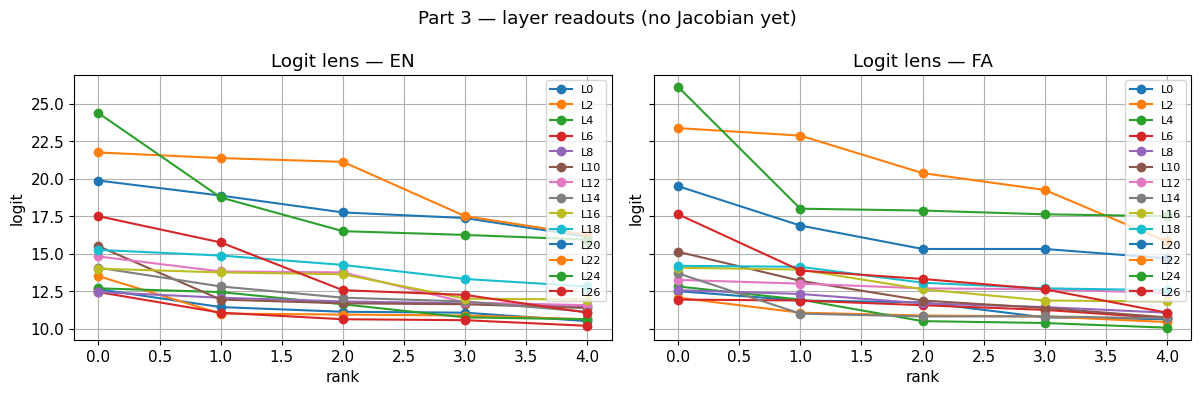

EN @ L14 [(' ', 14.06), ('<|endoftext|>', 12.81), ('Explanation', 12.06), (' Answer', 11.81), (' (', 11.12)]
FA @ L14 [(' ', 13.69), (' Answer', 11.0), ('<|endoftext|>', 10.81), (' (', 10.81), ('Answer', 10.69)]


In [32]:
def plot_jlens(res, title, ax):
    for layer, toks in res.top_tokens.items():
        vals = [t["logit"] for t in toks[:5]]
        ax.plot(range(len(vals)), vals, marker="o", label=f"L{layer}")
    ax.set_title(title)
    ax.set_xlabel("rank")
    ax.set_ylabel("logit")
    ax.legend(fontsize=8)

logit_en = run_jlens(
    model, PROMPT_EN, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K, use_jacobian=False,
)
logit_fa = run_jlens(
    model, PROMPT_FA, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K, use_jacobian=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_jlens(logit_en, "Logit lens — EN", axes[0])
plot_jlens(logit_fa, "Logit lens — FA", axes[1])
plt.suptitle("Part 3 — layer readouts (no Jacobian yet)")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_logit_lens_en_fa.png", dpi=150)
plt.show()

mid = SOURCE_LAYERS[len(SOURCE_LAYERS) // 2]
print("EN @ L" + str(mid), [(t["token"], round(t["logit"], 2)) for t in logit_en.top_tokens[mid][:5]])
print("FA @ L" + str(mid), [(t["token"], round(t["logit"], 2)) for t in logit_fa.top_tokens[mid][:5]])### 3.2 Logit lens (fast) — EN vs FA

### 3.3 Fit a small Jacobian lens (GPU recommended)

Start with few prompts; raise `N_FIT` later. Can take several minutes.

In [34]:
N_FIT = 10  # pairs → ~20 prompts; raise after smoke test
fit_pairs = culture_prompt_pairs(
    load_culture_questions(culture_json_path()),
    source_lang="english",
    target_lang="persian",
    limit=N_FIT,
)
fit_prompts = []
for p in fit_pairs:
    fit_prompts.append(p["source_prompt"])
    fit_prompts.append(p["target_prompt"])

SKIP_FIRST = 16
fit_prompts = [t for t in fit_prompts if len(t.split()) > SKIP_FIRST + 4]
if len(fit_prompts) < 2:
    fit_prompts = [PROMPT_EN, PROMPT_FA]

# Heavy: fit.ckpt / lens.pt are d×d × layers (GBs on 32B). Off = JSON + figures only.
SAVE_JLENS_FIT_CKPT = False
SAVE_JLENS_WEIGHTS = False
ckpt = str(OUT["jlens"] / "qwen_jlens_fit.ckpt") if SAVE_JLENS_FIT_CKPT else None
print(f"Fitting {len(fit_prompts)} prompts on {model.device} → ckpt={ckpt}")

lens = fit(
    jlens_model,
    fit_prompts,
    source_layers=SOURCE_LAYERS,
    target_layer=TARGET_LAYER,
    dim_batch=16,
    max_seq_len=128,
    skip_first=SKIP_FIRST,
    checkpoint_path=ckpt,
    checkpoint_every=1 if SAVE_JLENS_FIT_CKPT else None,
    resume=False,
)
if SAVE_JLENS_WEIGHTS:
    lens.save(str(OUT["jlens"] / "qwen_lens.pt"))
    print("saved", OUT["jlens"] / "qwen_lens.pt")
else:
    print("SKIPPED qwen_lens.pt / fit.ckpt (figures/numbers workflow)")
print("fitted layers=", lens.source_layers, "n_prompts=", lens.n_prompts)

Fitting 78 prompts on cuda → /content/drive/MyDrive/multilingual_mech/output/jlens/qwen_jlens_fit.ckpt
fitted layers= [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26] n_prompts= 78


### 3.4 Jacobian lens vs logit lens (shared EN item)

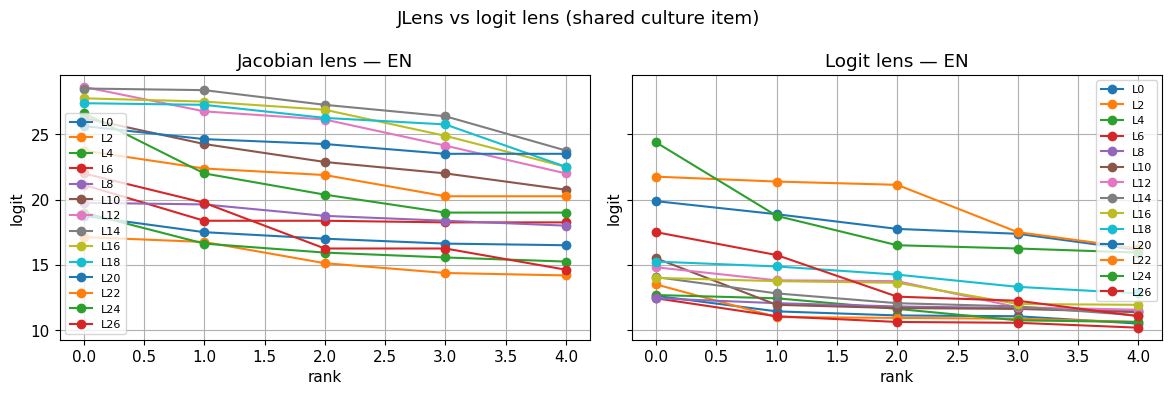

J L0: [('iri', 18.75), ('akin', 17.5), ('isma', 17.0), ('iting', 16.62)]
J L2: [('\xa0', 17.12), (' \n\n', 16.75), (' Mat', 15.12), (' \n', 14.38)]
J L4: [('\xa0', 19.0), (' \n\n', 16.62), ('\xa0\xa0', 15.94), (' Ans', 15.56)]
J L6: [('\xa0', 21.12), ('\xa0\xa0', 18.38), ('\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0', 18.38), ('\u200b\n\n', 18.25)]
J L8: [(':\n\n', 19.75), (':\n\n\n', 19.62), (' Ans', 18.75), ('\xa0', 18.38)]
J L10: [(':\n\n', 26.25), (':\n\n\n', 24.25), (' :\n\n', 22.88), (':\n\n\n\n', 22.0)]
J L12: [(':\n\n', 28.62), (':\n\n\n', 26.75), (' :\n\n', 26.12), (':\n\n\n\n', 24.12)]
J L14: [(':\n\n', 28.5), (':\n\n\n', 28.38), (' :\n\n', 27.25), (':\n\n\n\n', 26.38)]
J L16: [(':\n\n', 27.75), (':\n\n\n', 27.5), (' :\n\n', 26.88), (':\n\n\n\n', 24.88)]
J L18: [(':\n\n', 27.38), (' :\n\n', 27.25), (':\n\n\n', 26.25), (':\n\n\n\n', 25.75)]
J L20: [('\n\n\n\n', 25.62), ('\n\n\n', 24.62), (' :\n\n', 24.25), (':\n\n\n', 23.5)]
J L22: [(' C', 23.75), (' B', 22.38), (' BC', 21.88), ('\n\n\n'

In [35]:
jac_en = run_jlens(
    model, PROMPT_EN, lens=lens, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K, use_jacobian=True,
)
base_en = run_jlens(
    model, PROMPT_EN, lens=lens, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K, use_jacobian=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_jlens(jac_en, "Jacobian lens — EN", axes[0])
plot_jlens(base_en, "Logit lens — EN", axes[1])
plt.suptitle("JLens vs logit lens (shared culture item)")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_jlens_vs_logit.png", dpi=150)
plt.show()

for layer, toks in jac_en.top_tokens.items():
    print(f"J L{layer}:", [(t["token"], round(t["logit"], 2)) for t in toks[:4]])

### 3.4b Multi-position JLens + correct option letter

JLens is **not** only for the final `Answer:` token. We score:

1. last token (`Answer:`) — option letter readiness  
2. a mid-prompt **semantic** position (e.g. subject name token)  
3. trajectory of **P/rank of correct letter C** (not multi-token gold text)


In [ ]:
# --- Find token positions + track CORRECT_LETTER across layers ---
import numpy as np

def _find_substr_pos(prompt: str, needle: str) -> int:
    """Index of last token that overlaps `needle` in the prompt (fallback: -1)."""
    enc = model.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    ids = enc["input_ids"][0].tolist()
    # search for first token of needle
    needle_ids = model.tokenizer.encode(needle, add_special_tokens=False)
    if not needle_ids:
        return -1
    target = needle_ids[0]
    hits = [i for i, t in enumerate(ids) if t == target]
    return int(hits[-1]) if hits else -1

# Semantic anchors for item 1 style prompts; falls back gracefully
SEM_EN = "Hafez" if "Hafez" in PROMPT_EN else ANSWER.split()[0]
SEM_FA = "حافظ" if "حافظ" in PROMPT_FA else (ANSWER_FA[:2] if ANSWER_FA else "")

pos_answer = -1
pos_sem_en = _find_substr_pos(PROMPT_EN, SEM_EN)
pos_sem_fa = _find_substr_pos(PROMPT_FA, SEM_FA) if SEM_FA else -1
print(f"positions: answer={pos_answer}, EN '{SEM_EN}' -> {pos_sem_en}, FA '{SEM_FA}' -> {pos_sem_fa}")

use_j = "lens" in dir() and lens is not None
letter_id = model.tokenizer.encode(CORRECT_LETTER, add_special_tokens=False)[0]

def _letter_curve(prompt: str, positions):
    res = run_jlens(
        model, prompt, lens=lens if use_j else None,
        layers=SOURCE_LAYERS, positions=positions, top_k=TOP_K,
        use_jacobian=use_j,
    )
    # res.logits[L] is [n_pos, V] or [V] depending on apply
    layers, ranks, logits_c = [], [], []
    for L in SOURCE_LAYERS:
        logits = res.logits[L]
        if logits.ndim == 1:
            row = logits
        else:
            row = logits[-1]  # last requested position in this call
        order = row.argsort(descending=True)
        rank = int((order == letter_id).nonzero()[0].item()) + 1
        layers.append(L)
        ranks.append(rank)
        logits_c.append(float(row[letter_id]))
    return {"layers": layers, "rank": ranks, "logit": logits_c, "result": res}

# Answer-position curves (option letter)
curve_en_ans = _letter_curve(PROMPT_EN, [pos_answer])
curve_fa_ans = _letter_curve(PROMPT_FA, [pos_answer])

# Semantic-position readouts (top tokens) — different positions, not just Answer:
jlens_sem_en = run_jlens(
    model, PROMPT_EN, lens=lens if use_j else None,
    layers=SOURCE_LAYERS, positions=[pos_sem_en], top_k=TOP_K, use_jacobian=use_j,
) if pos_sem_en >= 0 else None
jlens_sem_fa = run_jlens(
    model, PROMPT_FA, lens=lens if use_j else None,
    layers=SOURCE_LAYERS, positions=[pos_sem_fa], top_k=TOP_K, use_jacobian=use_j,
) if pos_sem_fa >= 0 else None

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(curve_en_ans["layers"], np.log10(np.array(curve_en_ans["rank"])), "o-", label="EN", color="#4C78A8")
axes[0].plot(curve_fa_ans["layers"], np.log10(np.array(curve_fa_ans["rank"])), "s-", label="FA", color="#F58518")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("log10(rank of option letter)")
axes[0].set_title(f"Answer-pos: rank of '{CORRECT_LETTER}'")
axes[0].legend()

# Show mid-layer top tokens at semantic pos
mid = SOURCE_LAYERS[len(SOURCE_LAYERS) // 2]
axes[1].axis("off")
lines = [f"Semantic position mid-layer L{mid} top tokens", ""]
if jlens_sem_en is not None:
    lines.append("EN @" + repr(SEM_EN) + ": " + ", ".join(t["token"] for t in jlens_sem_en.top_tokens[mid][:6]))
if jlens_sem_fa is not None:
    lines.append("FA @" + repr(SEM_FA) + ": " + ", ".join(t["token"] for t in jlens_sem_fa.top_tokens[mid][:6]))
lines.append("")
lines.append(f"Answer-pos late rank EN={curve_en_ans['rank'][-1]} FA={curve_fa_ans['rank'][-1]}")
axes[1].text(0.0, 0.5, "\n".join(lines), fontsize=10, family="monospace", va="center")
plt.suptitle(f"JLens multi-position — item {pair.get('id')}")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_jlens_multipos_letter.png", dpi=150)
plt.show()

jlens_letter_summary = {
    "correct_letter": CORRECT_LETTER,
    "en_answer_pos": {k: curve_en_ans[k] for k in ("layers", "rank", "logit")},
    "fa_answer_pos": {k: curve_fa_ans[k] for k in ("layers", "rank", "logit")},
    "semantic_en": SEM_EN,
    "semantic_fa": SEM_FA,
}
save_json(jlens_letter_summary, OUT["jlens"] / "letter_trajectories.json")



### 3.5 Jacobian heatmaps (diagnostic)

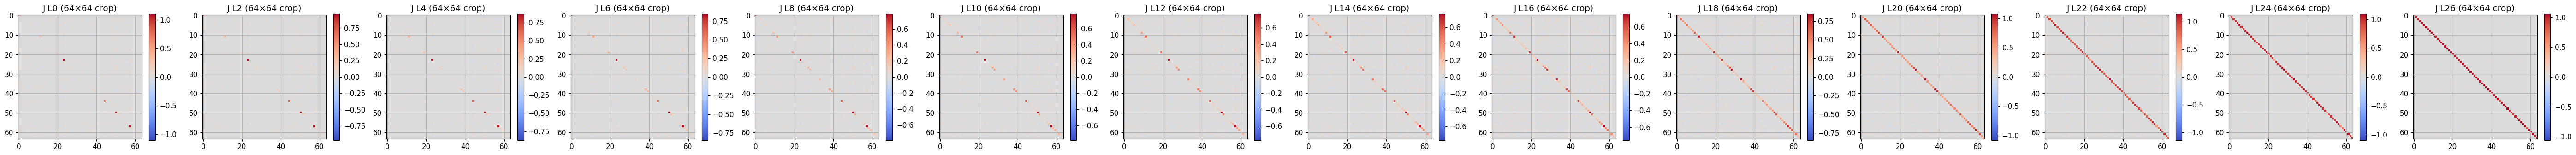

In [36]:
fig, axes = plt.subplots(1, len(lens.source_layers), figsize=(4 * len(lens.source_layers), 3.5))
if len(lens.source_layers) == 1:
    axes = [axes]
for ax, layer in zip(axes, lens.source_layers):
    J = lens.jacobians[layer]
    show = J[:64, :64].float().numpy()
    vmax = float(abs(show).max()) + 1e-8
    im = ax.imshow(show, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(f"J L{layer} (64×64 crop)")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_jacobian_heatmaps.png", dpi=150)
plt.show()

### 3.6 EN ↔ FA verbalizable concepts (JLens)

**Question:** For the same culture item, what does the residual “want to say” in English vs Persian — and when does the gold answer become readable?

We apply the **same fitted** \(J_\ell\) to:
- `PROMPT_EN` → readout vs gold `ANSWER`
- `PROMPT_FA` → readout vs gold `ANSWER_FA`

Plots: top-token panels, gold logit / rank / probability vs layer, and an EN–FA summary table.

In [37]:
import numpy as np
import torch.nn.functional as F

# Need fitted lens from 3.3
assert "lens" in dir() and lens is not None, "Run 3.3 fit first (lens=...)."

TOP_K_VIZ = max(TOP_K, 12)  # richer panels
tok = model.tokenizer

def _answer_token_ids(text: str) -> list[int]:
    text = (text or "").strip()
    if not text:
        return []
    # Prefer continuing-word tokenization without extra specials
    ids = tok.encode(text, add_special_tokens=False)
    if not ids:
        ids = tok.encode(" " + text, add_special_tokens=False)
    return list(ids)

def _score_gold(logits_1d: torch.Tensor, answer_ids: list[int]) -> dict:
    """Gold metrics from a [vocab] logit vector."""
    logits_1d = logits_1d.float().cpu()
    if not answer_ids:
        return {"logit": float("nan"), "prob": float("nan"), "rank": None, "token_id": None}
    # Use first answer token (standard next-token style); also track best among pieces
    first_id = int(answer_ids[0])
    piece_logits = [float(logits_1d[i]) for i in answer_ids if 0 <= i < logits_1d.numel()]
    best_id = int(answer_ids[int(np.argmax(piece_logits))]) if piece_logits else first_id

    order = torch.argsort(logits_1d, descending=True)
    rank_map = {int(t): r for r, t in enumerate(order.tolist())}
    probs = F.softmax(logits_1d, dim=-1)
    return {
        "logit": float(logits_1d[first_id]),
        "logit_best_piece": float(logits_1d[best_id]),
        "prob": float(probs[first_id]),
        "prob_best_piece": float(probs[best_id]),
        "rank": rank_map.get(first_id),
        "rank_best_piece": rank_map.get(best_id),
        "token_id": first_id,
        "token": tok.decode([first_id]),
        "n_pieces": len(answer_ids),
    }

def _layer_curves(result, answer_ids: list[int]) -> dict[str, list]:
    layers, logits, probs, ranks = [], [], [], []
    for L in result.layers:
        s = _score_gold(result.logits[L], answer_ids)
        layers.append(L)
        logits.append(s["logit"])
        probs.append(s["prob"])
        ranks.append(s["rank"] if s["rank"] is not None else np.nan)
    return {"layers": layers, "logit": logits, "prob": probs, "rank": ranks}

ids_en = _answer_token_ids(ANSWER)
ids_fa = _answer_token_ids(ANSWER_FA)
print("ANSWER    =", repr(ANSWER), "→ ids", ids_en, "→", [tok.decode([i]) for i in ids_en])
print("ANSWER_FA =", repr(ANSWER_FA), "→ ids", ids_fa, "→", [tok.decode([i]) for i in ids_fa])

jac_en = run_jlens(
    model, PROMPT_EN, lens=lens, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K_VIZ, use_jacobian=True,
)
jac_fa = run_jlens(
    model, PROMPT_FA, lens=lens, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K_VIZ, use_jacobian=True,
)
# logit-lens baselines (same layers) for comparison
base_en = run_jlens(
    model, PROMPT_EN, lens=lens, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K_VIZ, use_jacobian=False,
)
base_fa = run_jlens(
    model, PROMPT_FA, lens=lens, layers=SOURCE_LAYERS,
    positions=[-1], top_k=TOP_K_VIZ, use_jacobian=False,
)

curve_en = _layer_curves(jac_en, ids_en)
curve_fa = _layer_curves(jac_fa, ids_fa)
curve_en_ll = _layer_curves(base_en, ids_en)
curve_fa_ll = _layer_curves(base_fa, ids_fa)

print("JLens EN gold @ layers:", list(zip(curve_en["layers"], curve_en["rank"], [round(x, 3) for x in curve_en["logit"]])))
print("JLens FA gold @ layers:", list(zip(curve_fa["layers"], curve_fa["rank"], [round(x, 3) for x in curve_fa["logit"]])))

ANSWER    = 'Divan-e Hafez' → ids [12509, 276, 5655, 472, 5645, 89] → ['Div', 'an', '-e', ' H', 'afe', 'z']
ANSWER_FA = 'دیوان حافظ' → ids [13325, 14391, 126277, 68238, 125859] → ['د', 'ی', 'وان', ' ح', 'افظ']
JLens EN gold @ layers: [(0, 95395, -0.206), (2, 72552, 0.236), (4, 24693, 3.094), (6, 30204, 2.219), (8, 24841, 3.031), (10, 30669, 2.312), (12, 31190, 2.25), (14, 18912, 2.578), (16, 13724, 3.453), (18, 43497, 2.078), (20, 38787, 1.773), (22, 19512, 2.562), (24, 16231, 2.047), (26, 103, 9.75)]
JLens FA gold @ layers: [(0, 125511, -2.047), (2, 7980, 5.094), (4, 35629, 1.852), (6, 12668, 3.891), (8, 25172, 2.516), (10, 47651, 0.754), (12, 27941, 1.969), (14, 15682, 2.875), (16, 12821, 3.312), (18, 23388, 3.188), (20, 20207, 2.906), (22, 1603, 6.969), (24, 1128, 5.938), (26, 374, 5.562)]


#### Top-token panels by layer (EN | FA)

What the residual is verbalizing at each source layer (Jacobian lens).

/tmp/ipykernel_10911/1064956484.py:22: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10911/1064956484.py:22: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10911/1064956484.py:23: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["figures"] / "part3_6_topk_panels.png", dpi=160, bbox_inches="tight")
/tmp/ipykernel_10911/1064956484.py:23: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["figures"] / "part3_6_topk_panels.png", dpi=160, bbox_inches="tight")
/tmp/ipykernel_10911/1064956484.py:24: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["jlens"] / "en_fa_topk_panels.png", dpi=160, bbox_inches="tight")
/tmp/ipykernel_10911/1064956484.py:24: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["jlens"] / "en_fa_topk_pan

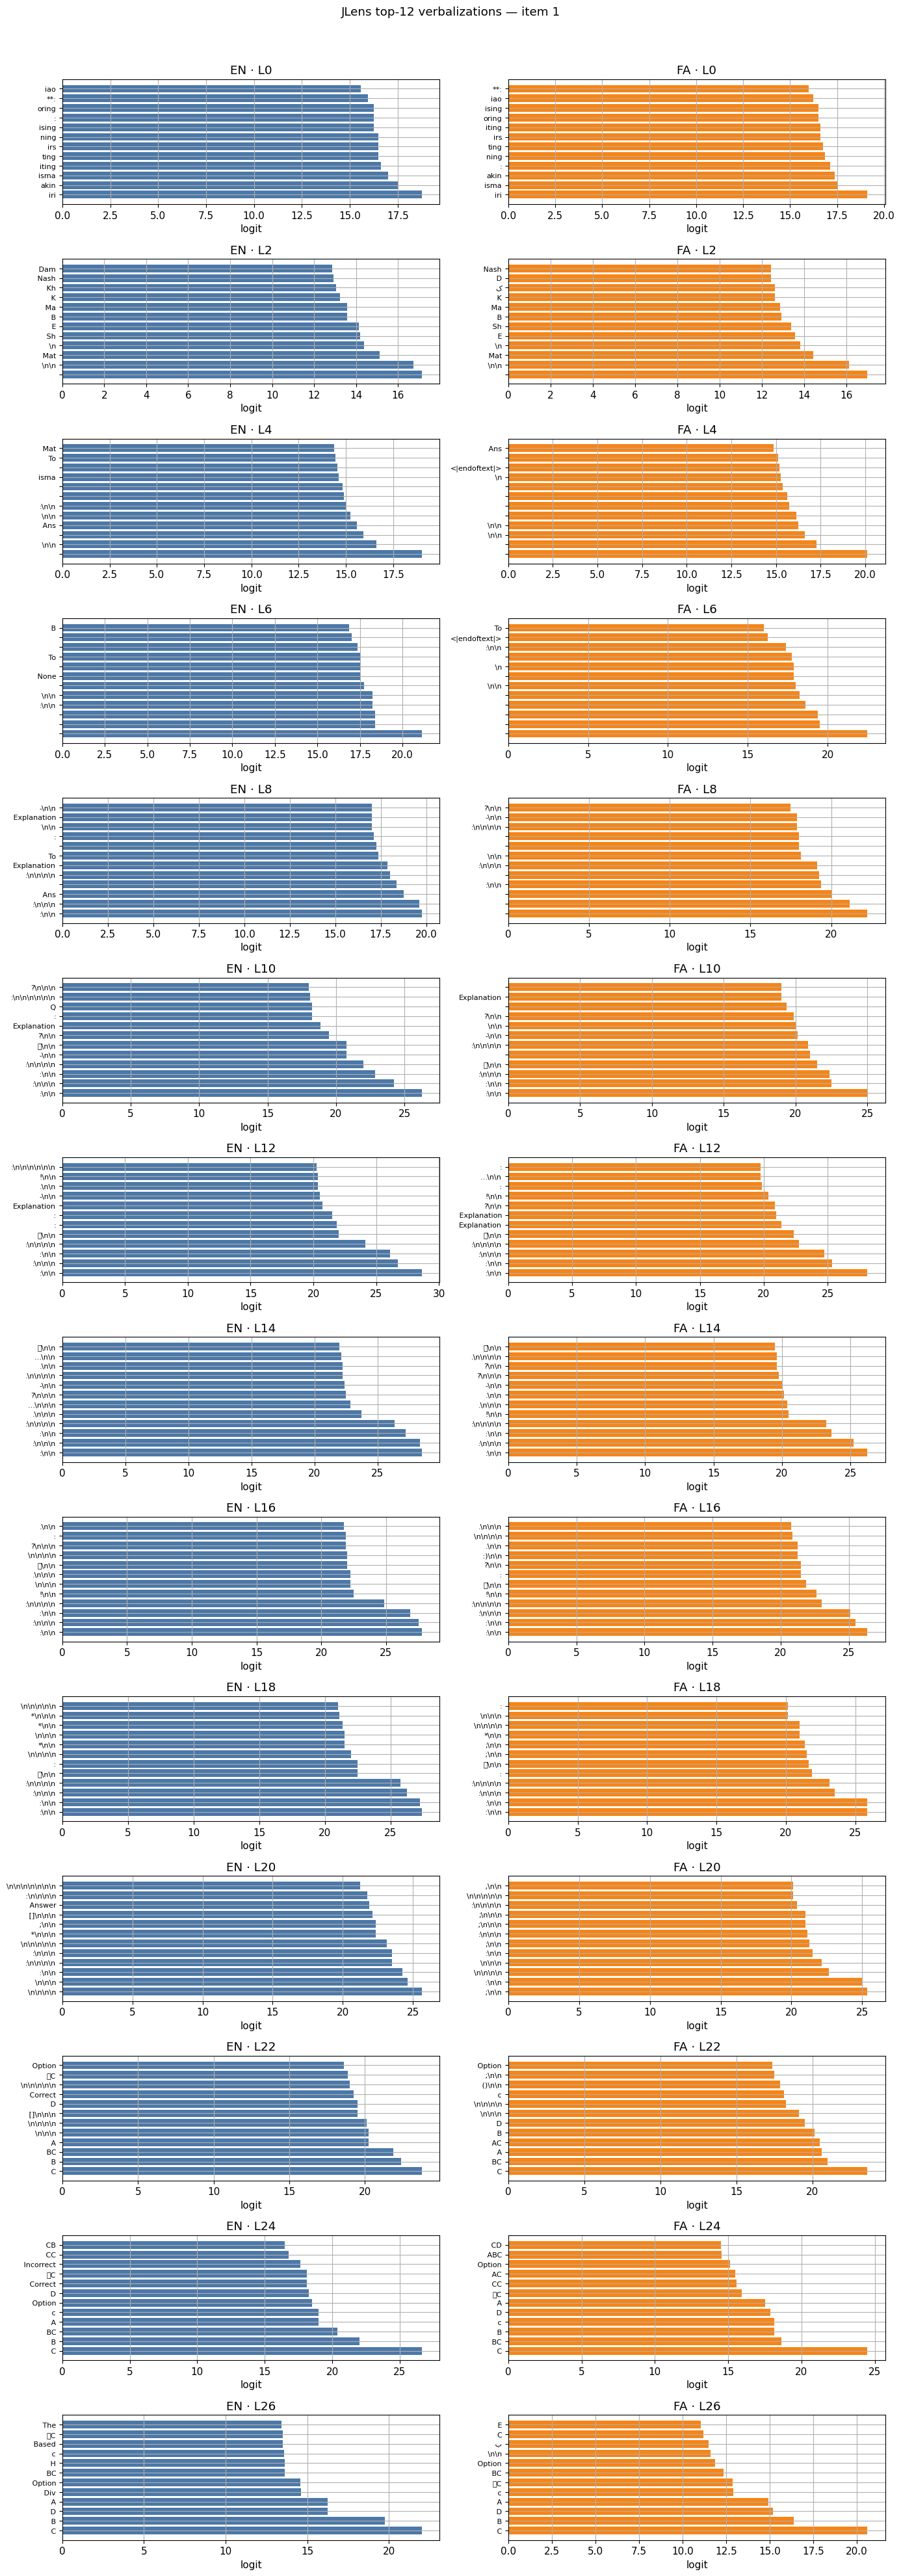

In [38]:
nL = len(SOURCE_LAYERS)
fig, axes = plt.subplots(nL, 2, figsize=(14, 2.8 * nL), sharex=False)
if nL == 1:
    axes = np.array([axes])

for i, L in enumerate(SOURCE_LAYERS):
    for col, (res, title, color) in enumerate([
        (jac_en, f"EN · L{L}", "#4C78A8"),
        (jac_fa, f"FA · L{L}", "#F58518"),
    ]):
        ax = axes[i, col]
        toks = res.top_tokens[L]
        labels = [t["token"].replace("\n", "\\n")[:18] for t in toks]
        vals = [t["logit"] for t in toks]
        ax.barh(range(len(vals))[::-1], vals[::-1], color=color)
        ax.set_yticks(range(len(vals))[::-1])
        ax.set_yticklabels(labels[::-1], fontsize=8)
        ax.set_title(title)
        ax.set_xlabel("logit")

plt.suptitle(f"JLens top-{TOP_K_VIZ} verbalizations — item {pair.get('id')}", y=1.01)
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_6_topk_panels.png", dpi=160, bbox_inches="tight")
fig.savefig(OUT["jlens"] / "en_fa_topk_panels.png", dpi=160, bbox_inches="tight")
plt.show()

#### Gold-answer trajectories

Layer-wise **logit**, **softmax probability**, and **rank** of the gold answer token  
(EN prompt → `ANSWER`, FA prompt → `ANSWER_FA`). Lower rank = more verbalizable.

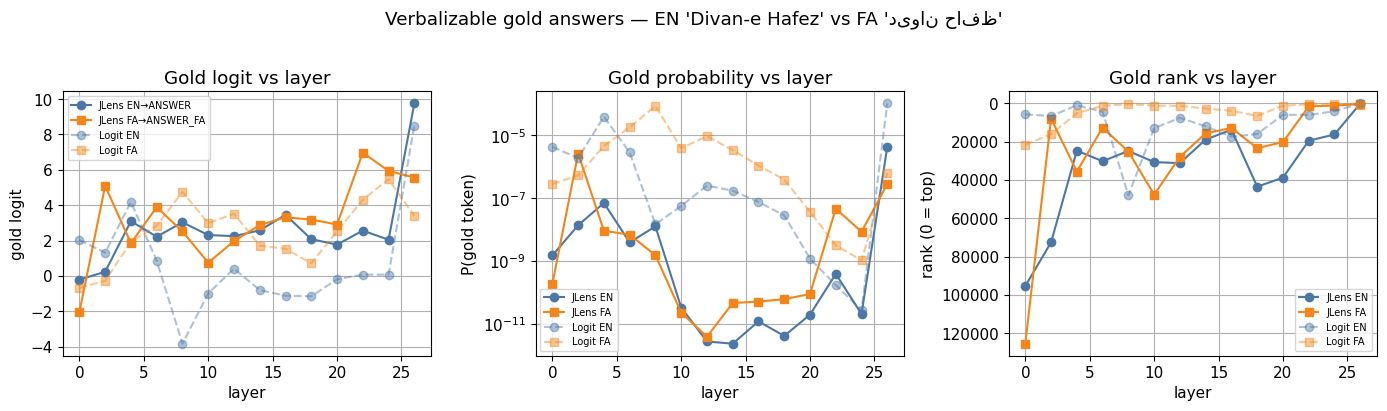

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) logit
axes[0].plot(curve_en["layers"], curve_en["logit"], "o-", color="#4C78A8", label="JLens EN→ANSWER")
axes[0].plot(curve_fa["layers"], curve_fa["logit"], "s-", color="#F58518", label="JLens FA→ANSWER_FA")
axes[0].plot(curve_en_ll["layers"], curve_en_ll["logit"], "o--", color="#4C78A8", alpha=0.45, label="Logit EN")
axes[0].plot(curve_fa_ll["layers"], curve_fa_ll["logit"], "s--", color="#F58518", alpha=0.45, label="Logit FA")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("gold logit")
axes[0].set_title("Gold logit vs layer")
axes[0].legend(fontsize=7)

# 2) probability
axes[1].plot(curve_en["layers"], curve_en["prob"], "o-", color="#4C78A8", label="JLens EN")
axes[1].plot(curve_fa["layers"], curve_fa["prob"], "s-", color="#F58518", label="JLens FA")
axes[1].plot(curve_en_ll["layers"], curve_en_ll["prob"], "o--", color="#4C78A8", alpha=0.45, label="Logit EN")
axes[1].plot(curve_fa_ll["layers"], curve_fa_ll["prob"], "s--", color="#F58518", alpha=0.45, label="Logit FA")
axes[1].set_xlabel("layer")
axes[1].set_ylabel("P(gold token)")
axes[1].set_title("Gold probability vs layer")
axes[1].set_yscale("log")
axes[1].legend(fontsize=7)

# 3) rank (invert y so better is up)
axes[2].plot(curve_en["layers"], curve_en["rank"], "o-", color="#4C78A8", label="JLens EN")
axes[2].plot(curve_fa["layers"], curve_fa["rank"], "s-", color="#F58518", label="JLens FA")
axes[2].plot(curve_en_ll["layers"], curve_en_ll["rank"], "o--", color="#4C78A8", alpha=0.45, label="Logit EN")
axes[2].plot(curve_fa_ll["layers"], curve_fa_ll["rank"], "s--", color="#F58518", alpha=0.45, label="Logit FA")
axes[2].set_xlabel("layer")
axes[2].set_ylabel("rank (0 = top)")
axes[2].set_title("Gold rank vs layer")
axes[2].invert_yaxis()
axes[2].legend(fontsize=7)

plt.suptitle(
    f"Verbalizable gold answers — EN {ANSWER!r} vs FA {ANSWER_FA!r}",
    y=1.02,
)
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_6_gold_trajectories.png", dpi=160, bbox_inches="tight")
fig.savefig(OUT["jlens"] / "en_fa_gold_trajectories.png", dpi=160, bbox_inches="tight")
plt.show()

#### Rank heatmap + EN–FA gap

Heatmap: how early the gold answer enters the top of the distribution.  
Gap plot: \(\mathrm{logit}_{EN}(ANSWER) - \mathrm{logit}_{FA}(ANSWER_{FA})\) by layer.

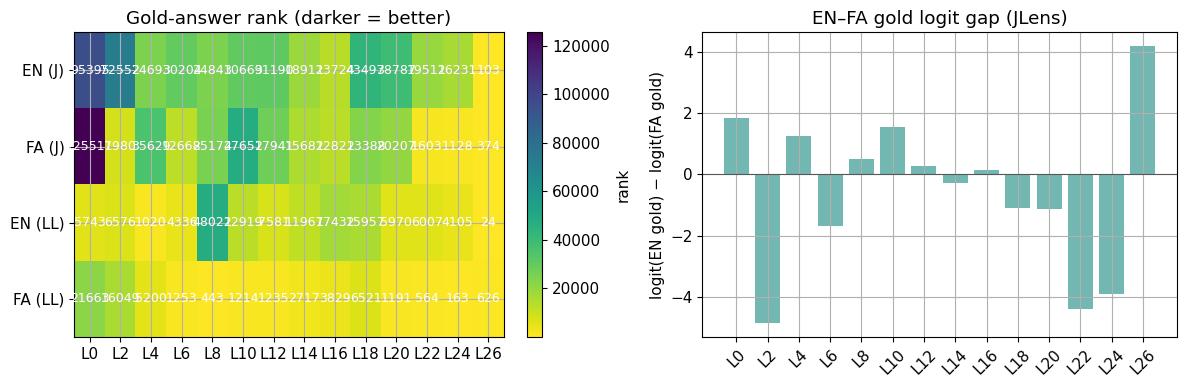

In [40]:
# Build rank matrix: rows = language, cols = layers
langs = ["EN (J)", "FA (J)", "EN (LL)", "FA (LL)"]
rank_mat = np.array([
    curve_en["rank"],
    curve_fa["rank"],
    curve_en_ll["rank"],
    curve_fa_ll["rank"],
], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(rank_mat, aspect="auto", cmap="viridis_r")
axes[0].set_yticks(range(len(langs)))
axes[0].set_yticklabels(langs)
axes[0].set_xticks(range(len(SOURCE_LAYERS)))
axes[0].set_xticklabels([f"L{L}" for L in SOURCE_LAYERS])
axes[0].set_title("Gold-answer rank (darker = better)")
for i in range(rank_mat.shape[0]):
    for j in range(rank_mat.shape[1]):
        val = rank_mat[i, j]
        axes[0].text(j, i, f"{int(val)}" if np.isfinite(val) else "—",
                     ha="center", va="center", color="white", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046, label="rank")

gap = np.array(curve_en["logit"]) - np.array(curve_fa["logit"])
axes[1].bar([f"L{L}" for L in curve_en["layers"]], gap, color="#72B7B2")
axes[1].axhline(0, color="k", lw=0.8, alpha=0.5)
axes[1].set_ylabel("logit(EN gold) − logit(FA gold)")
axes[1].set_title("EN–FA gold logit gap (JLens)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_6_rank_heatmap_gap.png", dpi=160, bbox_inches="tight")
fig.savefig(OUT["jlens"] / "en_fa_rank_gap.png", dpi=160, bbox_inches="tight")
plt.show()

#### Top-token overlap + summary table

Crude string overlap of top-k decoded tokens (same script helps EN; FA needs care).  
Still useful to see whether readouts converge to related surface forms.

,layer,en_gold_rank,fa_gold_rank,en_gold_prob,fa_gold_prob,overlap_n,en_top3,fa_top3
0,0,95395,125511,1.514156e-09,1.879503e-10,12,"[iri, akin, isma]","[iri, isma, akin]"
1,2,72552,7980,1.376083e-08,2.626085e-06,7,"[, , mat]","[, , mat]"
2,4,24693,35629,7.058611e-08,9.239264e-09,2,"[, , ]","[, , ]"
3,6,30204,12668,3.929623e-09,6.922834e-09,3,"[, , ]","[, , ]"
4,8,24841,25172,1.269002e-08,1.539869e-09,3,"[:, :, ans]","[, , ]"
5,10,30669,47651,3.350124e-11,2.329342e-11,5,"[:, :, :]","[:, :, :]"
6,12,31190,27941,2.801472e-12,3.931918e-12,4,"[:, :, :]","[:, :, :]"
7,14,18912,15682,2.376403e-12,4.651860e-11,5,"[:, :, :]","[:, :, :]"
8,16,13724,12821,1.218716e-11,5.176494e-11,5,"[:, :, :]","[:, :, :]"
9,18,43497,23388,4.203251e-12,6.173194e-11,3,"[:, :, :]","[:, :, :]"


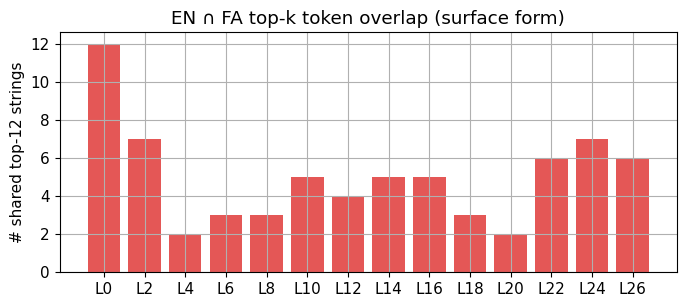

Saved /content/drive/MyDrive/multilingual_mech/output/jlens/en_fa_verbalizable.json


In [41]:
def _norm_tok(s: str) -> str:
    return s.replace("Ġ", "").replace("▁", "").strip().lower()

overlap_rows = []
for L in SOURCE_LAYERS:
    idx = SOURCE_LAYERS.index(L)
    en_set = {_norm_tok(t["token"]) for t in jac_en.top_tokens[L]}
    fa_set = {_norm_tok(t["token"]) for t in jac_fa.top_tokens[L]}
    inter = sorted(en_set & fa_set - {""})
    overlap_rows.append({
        "layer": L,
        "overlap_n": len(inter),
        "overlap_tokens": inter[:8],
        "en_top3": [_norm_tok(t["token"]) for t in jac_en.top_tokens[L][:3]],
        "fa_top3": [_norm_tok(t["token"]) for t in jac_fa.top_tokens[L][:3]],
        "en_gold_rank": curve_en["rank"][idx],
        "fa_gold_rank": curve_fa["rank"][idx],
        "en_gold_logit": curve_en["logit"][idx],
        "fa_gold_logit": curve_fa["logit"][idx],
        "en_gold_prob": curve_en["prob"][idx],
        "fa_gold_prob": curve_fa["prob"][idx],
    })

try:
    import pandas as pd
    df36 = pd.DataFrame(overlap_rows)
    display(df36[[
        "layer", "en_gold_rank", "fa_gold_rank",
        "en_gold_prob", "fa_gold_prob", "overlap_n", "en_top3", "fa_top3",
    ]])
except Exception:
    df36 = None
    for r in overlap_rows:
        print(r)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(
    [f"L{r['layer']}" for r in overlap_rows],
    [r["overlap_n"] for r in overlap_rows],
    color="#E45756",
)
ax.set_ylabel(f"# shared top-{TOP_K_VIZ} strings")
ax.set_title("EN ∩ FA top-k token overlap (surface form)")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_6_topk_overlap.png", dpi=160)
plt.show()

jlens_en_fa = {
    "item_id": pair.get("id"),
    "answer_en": ANSWER,
    "answer_fa": ANSWER_FA,
    "answer_ids_en": ids_en,
    "answer_ids_fa": ids_fa,
    "layers": list(SOURCE_LAYERS),
    "curves": {
        "jlens_en": curve_en,
        "jlens_fa": curve_fa,
        "logit_en": curve_en_ll,
        "logit_fa": curve_fa_ll,
    },
    "overlap": overlap_rows,
}

from multilingual_mechinterp.utils import save_json
save_json(jlens_en_fa, OUT["jlens"] / "en_fa_verbalizable.json")
print("Saved", OUT["jlens"] / "en_fa_verbalizable.json")

#### Concept board — what each language residual is saying

Side-by-side **decoded tokens** (not just curves).  
Left = English readout · Right = Persian readout · Center = same layer.

/tmp/ipykernel_10911/2671295517.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_10911/2671295517.py:61: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["figures"] / "part3_6_concept_board.png", dpi=180, bbox_inches="tight")
/tmp/ipykernel_10911/2671295517.py:62: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["jlens"] / "concept_board_en_fa.png", dpi=180, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


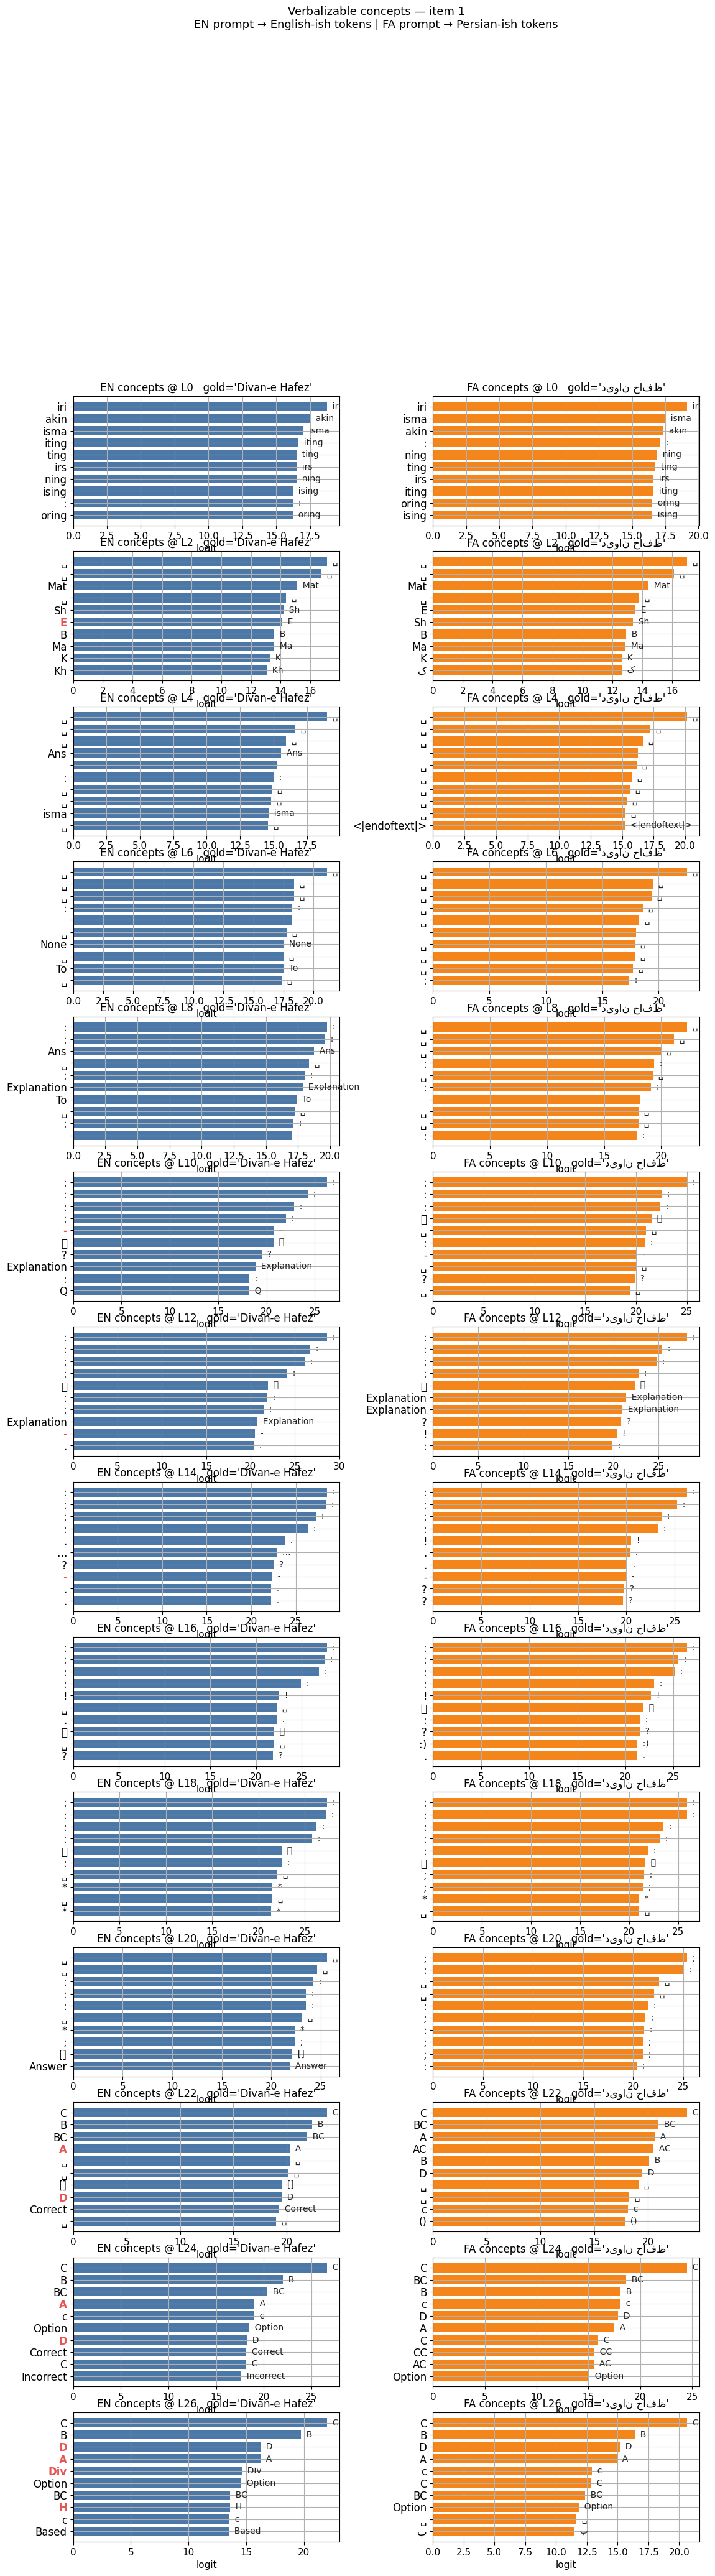

In [42]:
from matplotlib import font_manager
import matplotlib.pyplot as plt
import numpy as np

def _clean(tok: str) -> str:
    s = tok.replace("Ġ", " ").replace("▁", " ").replace("Ċ", "\\n")
    s = s.replace("\n", " ").strip()
    return s if s else "␣"

def _topk_labels(result, layer, k=10):
    rows = result.top_tokens[layer][:k]
    return [(_clean(t["token"]), t["logit"]) for t in rows]

# Pick layers to show as "concept boards"
board_layers = SOURCE_LAYERS  # or SOURCE_LAYERS[-2:] for late layers only
K = 10

fig, axes = plt.subplots(
    len(board_layers), 2,
    figsize=(13, 3.2 * len(board_layers)),
    gridspec_kw={"wspace": 0.35},
)
if len(board_layers) == 1:
    axes = np.array([axes])

for i, L in enumerate(board_layers):
    for col, (res, lang, color, gold) in enumerate([
        (jac_en, "EN", "#4C78A8", ANSWER),
        (jac_fa, "FA", "#F58518", ANSWER_FA),
    ]):
        ax = axes[i, col]
        pairs = _topk_labels(res, L, k=K)
        words = [p[0] for p in pairs][::-1]
        logits = [p[1] for p in pairs][::-1]

        y = np.arange(len(words))
        bars = ax.barh(y, logits, color=color, height=0.75)
        ax.set_yticks(y)
        ax.set_yticklabels(words, fontsize=12, fontfamily="DejaVu Sans")
        ax.set_xlabel("logit")
        ax.set_title(f"{lang} concepts @ L{L}   gold={gold!r}", fontsize=12)

        # highlight if gold string appears inside a decoded piece
        g = (gold or "").strip().lower()
        for tick, w in zip(ax.get_yticklabels(), words):
            if g and (g in w.lower() or w.lower() in g):
                tick.set_fontweight("bold")
                tick.set_color("#E45756")

        # write the word again at end of bar (readable even if y-labels clip)
        for yi, (w, val) in enumerate(zip(words, logits)):
            ax.text(val, yi, f"  {w}", va="center", fontsize=10, color="#222")

plt.suptitle(
    f"Verbalizable concepts — item {pair.get('id')}\n"
    f"EN prompt → English-ish tokens | FA prompt → Persian-ish tokens",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_6_concept_board.png", dpi=180, bbox_inches="tight")
fig.savefig(OUT["jlens"] / "concept_board_en_fa.png", dpi=180, bbox_inches="tight")
plt.show()

#### Concept pairs by layer (EN word ↔ FA word at same rank)

/tmp/ipykernel_10911/778753491.py:32: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10911/778753491.py:33: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.savefig(OUT["figures"] / "part3_6_concept_pairs.png", dpi=180, bbox_inches="tight")


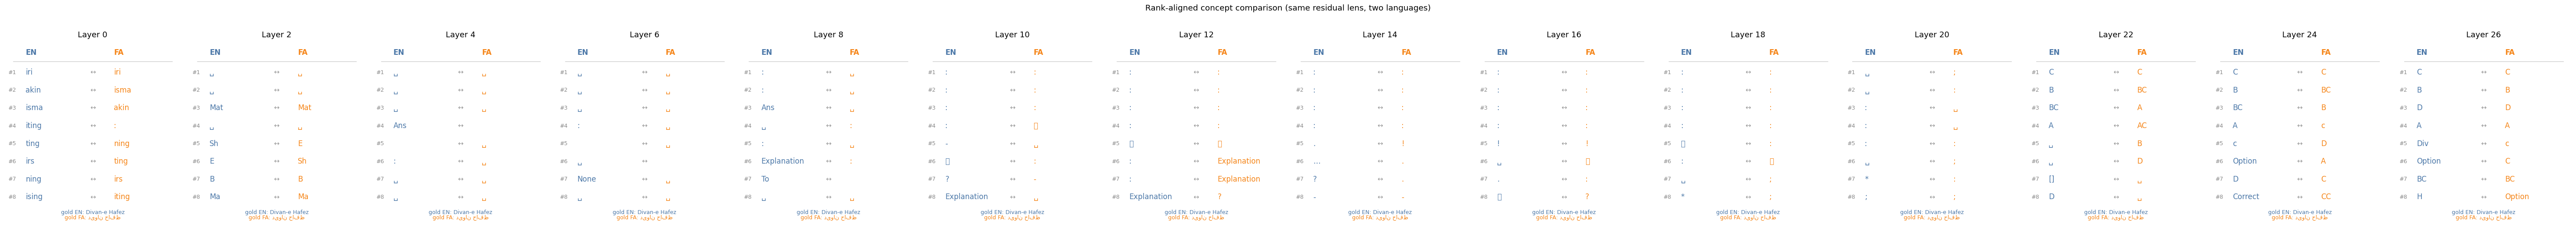


=== L0 ===
EN: ['iri', 'akin', 'isma', 'iting', 'ting', 'irs', 'ning', 'ising', ':', 'oring']
FA: ['iri', 'isma', 'akin', ':', 'ning', 'ting', 'irs', 'iting', 'oring', 'ising']

=== L2 ===
EN: ['␣', '␣', 'Mat', '␣', 'Sh', 'E', 'B', 'Ma', 'K', 'Kh']
FA: ['␣', '␣', 'Mat', '␣', 'E', 'Sh', 'B', 'Ma', 'K', 'ک']

=== L4 ===
EN: ['␣', '␣', '␣', 'Ans', '\u200b', ':', '␣', '␣', 'isma', '␣']
FA: ['␣', '␣', '␣', '\u200b', '␣', '␣', '␣', '␣', '␣', '<|endoftext|>']

=== L6 ===
EN: ['␣', '␣', '␣', ':', '\u200b', '␣', 'None', '␣', 'To', '␣']
FA: ['␣', '␣', '␣', '␣', '␣', '\u200b', '␣', '␣', '␣', ':']

=== L8 ===
EN: [':', ':', 'Ans', '␣', ':', 'Explanation', 'To', '␣', ':', '\u200b']
FA: ['␣', '␣', '␣', ':', '␣', ':', '\u200b', '␣', '␣', ':']

=== L10 ===
EN: [':', ':', ':', ':', '-', '：', '?', 'Explanation', ':', 'Q']
FA: [':', ':', ':', '：', '␣', ':', '-', '␣', '?', '␣']

=== L12 ===
EN: [':', ':', ':', ':', '：', ':', ':', 'Explanation', '-', '.']
FA: [':', ':', ':', ':', '：', 'Explanation', 'Expl

In [43]:
# Table-like figure: rank | EN token | FA token
K2 = 8
fig, axes = plt.subplots(1, len(SOURCE_LAYERS), figsize=(4.2 * len(SOURCE_LAYERS), 5))
if len(SOURCE_LAYERS) == 1:
    axes = [axes]

for ax, L in zip(axes, SOURCE_LAYERS):
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, K2 + 1.5)
    ax.axis("off")
    ax.set_title(f"Layer {L}", fontsize=13, pad=8)
    ax.text(0.12, K2 + 0.8, "EN", color="#4C78A8", fontsize=12, fontweight="bold")
    ax.text(0.62, K2 + 0.8, "FA", color="#F58518", fontsize=12, fontweight="bold")
    ax.plot([0.05, 0.95], [K2 + 0.4, K2 + 0.4], color="#ccc", lw=1)

    en = _topk_labels(jac_en, L, k=K2)
    fa = _topk_labels(jac_fa, L, k=K2)
    for r in range(K2):
        y = K2 - r - 0.2
        en_w, en_l = en[r]
        fa_w, fa_l = fa[r]
        ax.text(0.02, y, f"#{r+1}", fontsize=9, color="#888", va="center")
        ax.text(0.12, y, en_w[:22], fontsize=12, color="#4C78A8", va="center", fontfamily="DejaVu Sans")
        ax.text(0.50, y, "↔", fontsize=11, color="#999", va="center", ha="center")
        ax.text(0.62, y, fa_w[:22], fontsize=12, color="#F58518", va="center", fontfamily="DejaVu Sans")

    # gold footer
    ax.text(0.5, -0.15, f"gold EN: {ANSWER}", ha="center", fontsize=9, color="#4C78A8")
    ax.text(0.5, -0.45, f"gold FA: {ANSWER_FA}", ha="center", fontsize=9, color="#F58518")

plt.suptitle("Rank-aligned concept comparison (same residual lens, two languages)", y=1.02)
plt.tight_layout()
fig.savefig(OUT["figures"] / "part3_6_concept_pairs.png", dpi=180, bbox_inches="tight")
plt.show()

# Print explicit word lists too (easy to read in Colab output)
for L in SOURCE_LAYERS:
    print(f"\n=== L{L} ===")
    print("EN:", [w for w, _ in _topk_labels(jac_en, L, 10)])
    print("FA:", [w for w, _ in _topk_labels(jac_fa, L, 10)])

In [ ]:
# --- 3.7 Paper-style JLens slice (static matplotlib) ---
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import to_rgba

assert lens is not None
jlens_model = as_lens_model(model)
tok = model.tokenizer

def _clean(s: str) -> str:
    return s.replace("Ġ", " ").replace("▁", " ").replace("\n", "↵").strip() or "␣"

def _pin_ids(texts: list[str]) -> dict[str, int]:
    out = {}
    for t in texts:
        t = (t or "").strip()
        if not t:
            continue
        ids = tok.encode(t, add_special_tokens=False)
        if ids:
            out[t] = int(ids[0])  # first piece (same as next-token style)
    return out

def compute_argmax_board(prompt: str, layers: list[int], *, use_jacobian=True, max_pos=48):
    """Return token strings [n_layers, n_pos], ranks for pinned ids, and context strings."""
    lens_logits, model_logits, input_ids = lens.apply(
        jlens_model,
        prompt,
        layers=layers,
        positions=None,  # ALL positions — key for the paper grid
        max_seq_len=256,
        use_jacobian=use_jacobian,
    )
    ids = input_ids[0].tolist()
    if len(ids) > max_pos:
        # keep last max_pos tokens for readable boards
        start = len(ids) - max_pos
        ids = ids[start:]
        for L in list(lens_logits):
            lens_logits[L] = lens_logits[L][start:]
        model_logits = model_logits[start:]
    else:
        start = 0

    ctx = [_clean(tok.decode([i])) for i in ids]
    # include final layer as identity readout (model output row)
    final = jlens_model.n_layers - 1
    layer_list = list(layers)
    if final not in layer_list:
        # approximate final row from model_logits
        pass

    # argmax grid
    grid_ids = []
    grid_strs = []
    for L in layer_list:
        logits = lens_logits[L]  # [T, V]
        top_id = logits.argmax(dim=-1)  # [T]
        grid_ids.append(top_id.numpy())
        grid_strs.append([_clean(tok.decode([int(i)])) for i in top_id.tolist()])

    return {
        "ctx": ctx,
        "layers": layer_list,
        "grid_strs": np.array(grid_strs, dtype=object),  # [L, T]
        "grid_ids": np.array(grid_ids),
        "lens_logits": lens_logits,
        "ctx_offset": start,
    }

# Layers: use fitted sources (add more in fit for denser boards)
BOARD_LAYERS = list(SOURCE_LAYERS)
pins_en = _pin_ids([ANSWER, "the", "and"])  # edit concepts to track
pins_fa = _pin_ids([ANSWER_FA])

board_en = compute_argmax_board(PROMPT_EN, BOARD_LAYERS, use_jacobian=True, max_pos=40)
board_fa = compute_argmax_board(PROMPT_FA, BOARD_LAYERS, use_jacobian=True, max_pos=40)

def plot_argmax_board(board, pins: dict[str, int], title: str, path):
    layers = board["layers"]
    ctx = board["ctx"]
    grid = board["grid_strs"]
    nL, nT = grid.shape

    # color if cell token matches a pinned concept id
    pin_colors = {
        name: c for name, c in zip(
            pins,
            ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2", "#72B7B2"],
        )
    }
    id_to_name = {i: n for n, i in pins.items()}

    fig, ax = plt.subplots(figsize=(max(10, nT * 0.55), max(3.5, nL * 0.55)))
    ax.set_xlim(-0.5, nT - 0.5)
    ax.set_ylim(-0.5, nL - 0.5)
    ax.invert_yaxis()
    ax.set_xticks(range(nT))
    ax.set_xticklabels(ctx, rotation=90, fontsize=8)
    ax.set_yticks(range(nL))
    ax.set_yticklabels([f"L{L}" for L in layers])
    ax.set_xlabel("position (token)")
    ax.set_ylabel("layer")
    ax.set_title(title)

    for i in range(nL):
        for j in range(nT):
            word = str(grid[i, j])[:10]
            # map back via board grid_ids if available
            tid = int(board["grid_ids"][i, j])
            face = "#f5f5f5"
            for name, pid in pins.items():
                if tid == pid:
                    face = to_rgba(pin_colors[name], 0.55)
                    break
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=face, edgecolor="#ddd"))
            ax.text(j, i, word, ha="center", va="center", fontsize=7)

    # legend
    handles = [
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=pin_colors[n],
                   markersize=12, label=f"{n}")
        for n in pins
    ]
    if handles:
        ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

    plt.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

plot_argmax_board(
    board_en, pins_en,
    f"JLens ARGMAX — EN · item {pair.get('id')}",
    OUT["figures"] / "part3_7_argmax_en.png",
)
plot_argmax_board(
    board_fa, pins_fa,
    f"JLens ARGMAX — FA · item {pair.get('id')}",
    OUT["figures"] / "part3_7_argmax_fa.png",
)

In [ ]:
def rank_heatmap(board, token_id: int, title: str, path):
    layers = board["layers"]
    ctx = board["ctx"]
    ranks = []
    for L in layers:
        logits = board["lens_logits"][L]  # [T, V]
        # rank 0 = best
        order = torch.argsort(logits, dim=-1, descending=True)
        # find rank of token_id at each pos
        # (vectorized)
        matches = (order == token_id).nonzero(as_tuple=False)
        r = torch.full((logits.shape[0],), fill_value=logits.shape[1], dtype=torch.long)
        for pos, rank in matches.tolist():
            if r[pos] > rank:
                r[pos] = rank
        ranks.append(r.numpy())
    R = np.array(ranks, dtype=float)  # [L, T]
    R = np.log10(R + 1)  # log rank like the paper UI

    fig, ax = plt.subplots(figsize=(max(10, len(ctx) * 0.45), max(3, len(layers) * 0.45)))
    im = ax.imshow(R, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ctx)))
    ax.set_xticklabels(ctx, rotation=90, fontsize=8)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels([f"L{L}" for L in layers])
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.03, label="log10(rank+1)")
    plt.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

if ANSWER and pins_en.get(ANSWER):
    rank_heatmap(
        board_en, pins_en[ANSWER],
        f"Rank of {ANSWER!r} — EN",
        OUT["figures"] / "part3_7_rank_en.png",
    )
if ANSWER_FA and pins_fa.get(ANSWER_FA):
    rank_heatmap(
        board_fa, pins_fa[ANSWER_FA],
        f"Rank of {ANSWER_FA!r} — FA",
        OUT["figures"] / "part3_7_rank_fa.png",
    )

## Part 4 — Activation patching

Causal layer sweep: cache **EN** residuals, patch them into the **FA** run, plot  
$\Delta P(\text{answer})$ vs start layer, then recommend layers to swap.

Docs: `docs/activation_patching_reimpl/`

### 4.1 Run EN → FA patching on the shared culture item

Source = English MCQ · Target = Persian MCQ · Metric = **correct option letter** margin:

$$\Delta M = M_{\text{patched}} - M_{\text{FA baseline}},\quad M = L_C - \max(L_{A,B,D})$$

(Do **not** score English answer text like `"Divan-e"` inside the Persian prompt.)



In [44]:
from multilingual_mechinterp.patching import recommend_layers, run_patching
from multilingual_mechinterp.models.loader import LoadedModel

if not isinstance(model, LoadedModel):
    raise TypeError("Reload Cell 5: model = load_experiment_model()")

patch_cfg = cfg.get("patching", {})
MAX_CHARS = 400
src = PROMPT_EN[:MAX_CHARS]
tgt = PROMPT_FA[:MAX_CHARS]
# Score the correct MCQ letter (A–D), not the gold answer string
answer = CORRECT_LETTER

print(f"device={model.device}  n_layers={model.n_layers}")
print(f"metric=margin  answer_letter={answer!r}  (was wrongly using answer text before)")
print("--- source (EN) ---")
print(src[:240])
print("--- target (FA) ---")
print(tgt[:240])

patch = run_patching(
    model,
    source_prompt=src,
    target_prompt=tgt,
    answer=answer,
    metric="margin",
    source_pos=patch_cfg.get("source_pos", -1),
    target_pos=patch_cfg.get("target_pos", -1),
    window=patch_cfg.get("window"),
    device=str(model.device),
)

rec = recommend_layers(patch, top_k=3, min_effect=-1e9)
print("baseline margin M(FA) =", round(patch.baseline_score or 0.0, 4))
print("best_layer =", patch.best_layer)
print("recommend_layers =", rec)
print("max ΔM =", round(max(patch.scores.values()) if patch.scores else 0.0, 4))



device=cuda  n_layers=28
answer='Divan-e'
--- source (EN) ---
Which poetic collection by Hafez is traditionally used in Iran for fal-e Hafez?

A. Divan-e Saadi
B. Bustan-e Hafez
C. Divan-e Hafez
D. Golestan-e Saadi

Answer:
--- target (FA) ---
کدام مجموعه شعری حافظ به‌طور سنتی در ایران برای فال حافظ استفاده می‌شود؟

A. دیوان سعدی
B. بوستان حافظ
C. دیوان حافظ
D. گلستان سعدی

Answer:
baseline P(answer) = 0.0
best_layer = 0
recommend_layers = [0, 1, 2]


### 4.2 Causal-effect curve

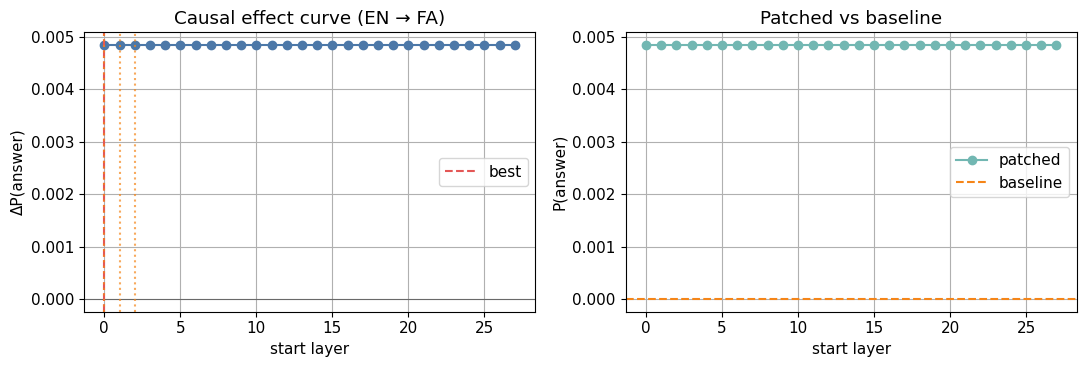

In [45]:
xs = sorted(patch.scores)
ys = [patch.scores[L] for L in xs]
ps = [patch.patched_probs[L] for L in xs]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(xs, ys, marker="o", color="#4C78A8")
axes[0].axhline(0, color="k", lw=0.8, alpha=0.4)
if patch.best_layer is not None:
    axes[0].axvline(patch.best_layer, color="#E45756", ls="--", label="best")
for L in rec:
    axes[0].axvline(L, color="#F58518", ls=":", alpha=0.7)
axes[0].set_xlabel("start layer")
axes[0].set_ylabel("ΔM(answer)")
axes[0].set_title("Causal effect curve (EN → FA)")
axes[0].legend()

axes[1].plot(xs, ps, marker="o", color="#72B7B2", label="patched")
axes[1].axhline(patch.baseline_score or 0.0, color="#F58518", ls="--", label="baseline")
axes[1].set_xlabel("start layer")
axes[1].set_ylabel("M (option margin)")
axes[1].set_title("Patched vs baseline")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUT["figures"] / "part4_causal_effect.png", dpi=150)
fig.savefig(OUT["patching"] / "causal_effect_curve.png", dpi=150)
plt.show()

### 4.3 (Optional) second culture item

Change `ITEM_B` to compare another question’s best layer.

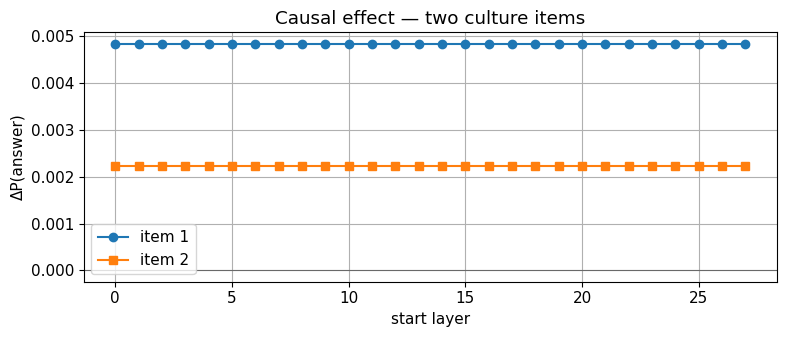

item B best_layer = 0 baseline = 0.0


In [46]:
ITEM_B = 1
pairs_b = culture_prompt_pairs(
    load_culture_questions(culture_json_path()),
    source_lang="english",
    target_lang="persian",
    limit=ITEM_B + 1,
)
pair_b = pairs_b[ITEM_B]
ans_b = pair_b["source_answer"].strip().split()[0]

patch_b = run_patching(
    model,
    source_prompt=pair_b["source_prompt"][:MAX_CHARS],
    target_prompt=pair_b["target_prompt"][:MAX_CHARS],
    answer=ans_b,
    metric="margin",
    device=str(model.device),
)

xs_b = sorted(patch_b.scores)
ys_b = [patch_b.scores[L] for L in xs_b]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(xs, ys, marker="o", label=f"item {pair.get('id')}")
ax.plot(xs_b, ys_b, marker="s", label=f"item {pair_b.get('id')}")
ax.axhline(0, color="k", lw=0.8, alpha=0.4)
ax.set_xlabel("start layer")
ax.set_ylabel("ΔP(answer)")
ax.set_title("Causal effect — two culture items")
ax.legend()
plt.tight_layout()
fig.savefig(OUT["figures"] / "part4_two_items.png", dpi=150)
plt.show()

print("item B best_layer =", patch_b.best_layer, "baseline =", round(patch_b.baseline_score or 0, 4))

## Part 5 — Common example (one item × three methods)

One coherent story for the shared EN↔FA MCQ:

1. **Baseline** — EN vs FA P(correct letter) / margin  
2. **SAE** — features that differ between EN and FA on this pair  
3. **JLens** — rank of correct option letter by layer (answer position)  
4. **Patching** — Δ margin when EN residuals are patched into FA  



### 5.1 Recap the shared item

In [47]:
print("id =", pair.get("id"))
print("ANSWER =", ANSWER, "| FA =", ANSWER_FA)
print("--- EN ---")
print(PROMPT_EN[:400])
print("--- FA ---")
print(PROMPT_FA[:400])

id = 1
ANSWER = Divan-e Hafez | FA = دیوان حافظ
--- EN ---
Which poetic collection by Hafez is traditionally used in Iran for fal-e Hafez?

A. Divan-e Saadi
B. Bustan-e Hafez
C. Divan-e Hafez
D. Golestan-e Saadi

Answer:
--- FA ---
کدام مجموعه شعری حافظ به‌طور سنتی در ایران برای فال حافظ استفاده می‌شود؟

A. دیوان سعدی
B. بوستان حافظ
C. دیوان حافظ
D. گلستان سعدی

Answer:


### 5.2 SAE snapshot (from Part 2)

Uses the mid-α checkpoint and residual acts already extracted.

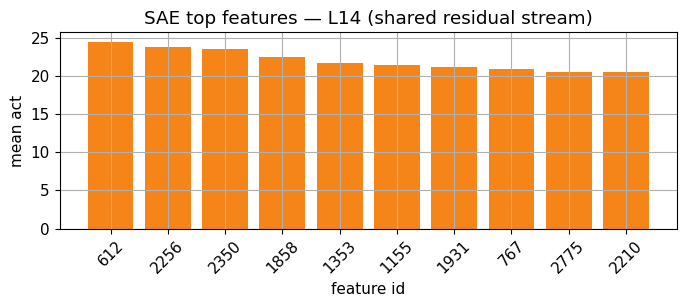

{'layer': 14, 'mid_alpha': 0.00086, 'fvu': 0.010089032351970673, 'mean_l0': 922.208984375, 'top_features': [612, 2256, 2350, 1858, 1353, 1155, 1931, 767, 2775, 2210]}


In [48]:
# Prefer pair contrast from Part 2.6; else compute quickly
if "sae_pair_contrast" not in dir():
    print("Run Part 2.6 for EN/FA SAE contrast; falling back to global top features.")
    sae_viz = TiedSAE.load(rows[len(rows) // 2]["checkpoint"], device="cpu")
    x = acts.detach().float().cpu()[: min(512, acts.shape[0])]
    with torch.no_grad():
        codes = sae_viz.encode(x)
    topk = torch.topk(codes.mean(0), k=10)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.bar([str(int(i)) for i in topk.indices], topk.values.numpy(), color="#F58518")
    ax.set_title(f"SAE top features — L{SAE_LAYER}")
    plt.tight_layout()
    fig.savefig(OUT["figures"] / "part5_sae.png", dpi=150)
    plt.show()
    sae_summary = {
        "layer": SAE_LAYER,
        "mid_alpha": rows[len(rows) // 2]["alpha"],
        "fvu": rows[len(rows) // 2]["fvu"],
        "mean_l0": rows[len(rows) // 2]["mean_l0"],
        "top_features": [int(i) for i in topk.indices],
        "mode": "global",
    }
else:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    idx = sae_pair_contrast["feature_ids"]
    x = np.arange(len(idx))
    w = 0.38
    ax.bar(x - w/2, sae_pair_contrast["mean_en"], w, label="EN", color="#4C78A8")
    ax.bar(x + w/2, sae_pair_contrast["mean_fa"], w, label="FA", color="#F58518")
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in idx], rotation=45)
    ax.set_title(f"SAE EN vs FA contrast — L{SAE_LAYER}")
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUT["figures"] / "part5_sae.png", dpi=150)
    plt.show()
    sae_summary = {
        "layer": SAE_LAYER,
        "mid_alpha": rows[len(rows) // 2]["alpha"],
        "fvu": rows[len(rows) // 2]["fvu"],
        "mean_l0": rows[len(rows) // 2]["mean_l0"],
        "top_differing_features": idx,
        "mode": "en_fa_contrast",
    }
print(sae_summary)



### 5.3 JLens snapshot (from Part 3)

Prefer fitted Jacobian lens if `lens` exists; else logit lens.

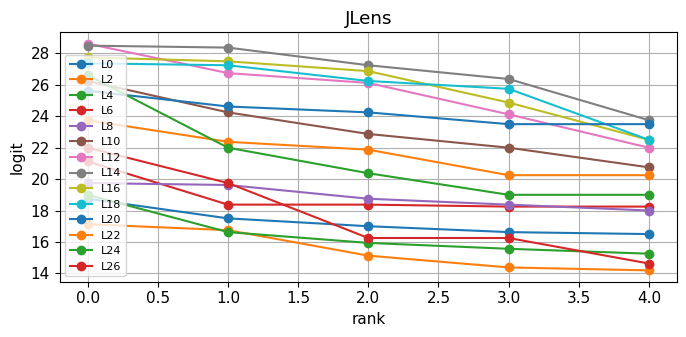

{'mode': 'jacobian', 'layers': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26], 'top_mid': [(':\n\n', 28.5), (':\n\n\n', 28.38), (' :\n\n', 27.25), (':\n\n\n\n', 26.38), ('.\n\n\n', 23.75)]}


In [49]:
use_j = "lens" in dir() and lens is not None
if "curve_en_ans" in dir():
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(curve_en_ans["layers"], np.log10(np.array(curve_en_ans["rank"]) + 0), "o-", label=f"EN rank({CORRECT_LETTER})")
    ax.plot(curve_fa_ans["layers"], np.log10(np.array(curve_fa_ans["rank"]) + 0), "s-", label=f"FA rank({CORRECT_LETTER})")
    ax.set_xlabel("layer")
    ax.set_ylabel("log10(rank)")
    ax.set_title("JLens: correct option letter becomes readable")
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUT["figures"] / "part5_jlens.png", dpi=150)
    plt.show()
    jlens_summary = {
        "mode": "jacobian" if use_j else "logit",
        "correct_letter": CORRECT_LETTER,
        "en_late_rank": curve_en_ans["rank"][-1],
        "fa_late_rank": curve_fa_ans["rank"][-1],
        "layers": SOURCE_LAYERS,
    }
else:
    jlens_out = run_jlens(
        model, PROMPT_EN, lens=lens if use_j else None,
        layers=SOURCE_LAYERS, positions=[-1], top_k=8, use_jacobian=use_j,
    )
    mid_L = SOURCE_LAYERS[len(SOURCE_LAYERS) // 2]
    jlens_summary = {
        "mode": "jacobian" if use_j else "logit",
        "layers": SOURCE_LAYERS,
        "top_mid": [(t["token"], round(t["logit"], 2)) for t in jlens_out.top_tokens[mid_L][:5]],
    }
    print("Run Part 3.4b for letter trajectories; showing mid-layer tops:", jlens_summary["top_mid"])
print(jlens_summary)



### 5.4 Patching snapshot (from Part 4)

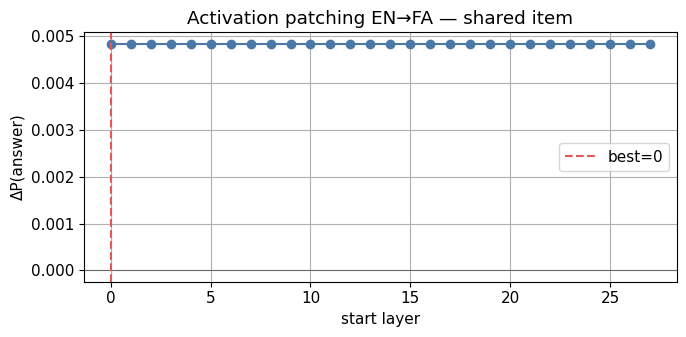

{'baseline': 0.0, 'best_layer': 0, 'recommend_layers': [0, 1, 2], 'answer': 'Divan-e Hafez'}


In [50]:
# Expects Part 4 `patch` with metric=margin
xs = sorted(patch.scores)
ys = [patch.scores[L] for L in xs]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(xs, ys, marker="o", color="#4C78A8")
ax.axhline(0, color="k", lw=0.8, alpha=0.4)
ax.set_xlabel("start layer")
ax.set_ylabel("ΔM (option margin)")
ax.set_title(f"Patching EN→FA — Δ margin for letter {CORRECT_LETTER}")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part5_patching.png", dpi=150)
plt.show()

patch_summary = {
    "baseline_margin": patch.baseline_score,
    "best_layer": patch.best_layer,
    "recommend_layers": recommend_layers(patch, top_k=3, min_effect=-1e9),
    "max_delta_margin": max(patch.scores.values()) if patch.scores else None,
    "answer_letter": CORRECT_LETTER,
    "metric": "margin",
}
print(patch_summary)



### 5.5 Combined dashboard

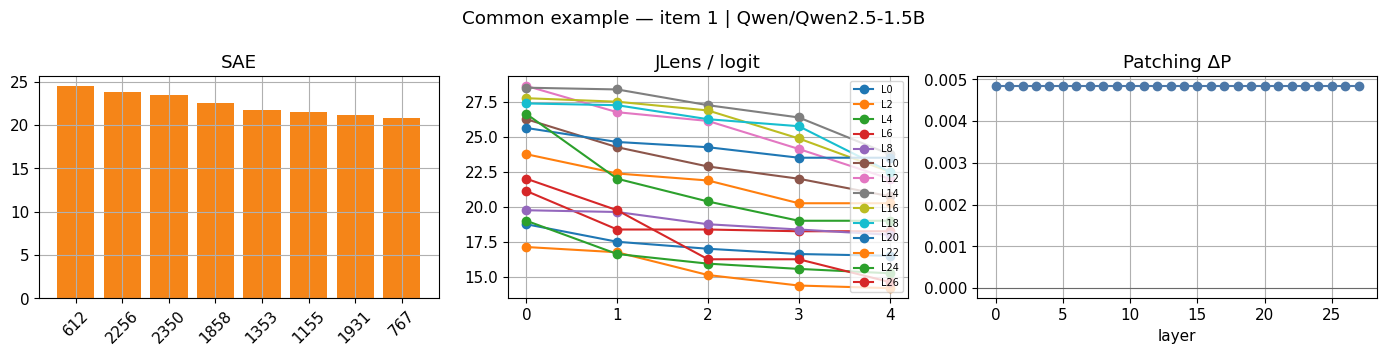

{'item_id': '1',
 'model': 'Qwen/Qwen2.5-1.5B',
 'sae': {'layer': 14,
  'mid_alpha': 0.00086,
  'fvu': 0.010089032351970673,
  'mean_l0': 922.208984375,
  'top_features': [612, 2256, 2350, 1858, 1353, 1155, 1931, 767, 2775, 2210]},
 'jlens': {'mode': 'jacobian',
  'layers': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26],
  'top_mid': [(':\n\n', 28.5),
   (':\n\n\n', 28.38),
   (' :\n\n', 27.25),
   (':\n\n\n\n', 26.38),
   ('.\n\n\n', 23.75)]},
 'patching': {'baseline': 0.0,
  'best_layer': 0,
  'recommend_layers': [0, 1, 2],
  'answer': 'Divan-e Hafez'}}

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# SAE contrast
if "sae_pair_contrast" in dir():
    idx = sae_pair_contrast["feature_ids"][:8]
    x = np.arange(len(idx))
    axes[0].bar(x - 0.2, [sae_pair_contrast["mean_en"][i] for i in range(len(idx))], 0.4, label="EN", color="#4C78A8")
    axes[0].bar(x + 0.2, [sae_pair_contrast["mean_fa"][i] for i in range(len(idx))], 0.4, label="FA", color="#F58518")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(i) for i in idx], rotation=45, fontsize=7)
    axes[0].set_title("SAE EN vs FA")
    axes[0].legend(fontsize=7)
else:
    axes[0].text(0.5, 0.5, "run SAE contrast", ha="center")

# JLens letter rank
if "curve_en_ans" in dir():
    axes[1].plot(curve_en_ans["layers"], np.log10(np.array(curve_en_ans["rank"])), "o-", label="EN")
    axes[1].plot(curve_fa_ans["layers"], np.log10(np.array(curve_fa_ans["rank"])), "s-", label="FA")
    axes[1].set_title(f"JLens rank({CORRECT_LETTER})")
    axes[1].legend(fontsize=7)
else:
    axes[1].text(0.5, 0.5, "run JLens 3.4b", ha="center")

# Patching
if "patch" in dir():
    xs = sorted(patch.scores)
    axes[2].plot(xs, [patch.scores[L] for L in xs], marker="o", color="#4C78A8")
    axes[2].axhline(0, color="k", lw=0.8, alpha=0.4)
    axes[2].set_title("Patching ΔM")
else:
    axes[2].text(0.5, 0.5, "run Part 4", ha="center")

plt.suptitle(
    f"Common example — item {pair.get('id')} | letter={CORRECT_LETTER} | "
    f"EN P={baseline_en['p_correct']:.2f} FA P={baseline_fa['p_correct']:.2f}"
)
plt.tight_layout()
fig.savefig(OUT["figures"] / "part5_dashboard.png", dpi=150)
fig.savefig(OUT["comparison"] / "common_example_dashboard.png", dpi=150)
plt.show()

# Explicit method comparison table (proposal criteria)
comparison_rows = [
    {
        "method": "Baseline",
        "analyses": "next-token A–D",
        "main_result": f"EN P={baseline_en['p_correct']:.3f} FA P={baseline_fa['p_correct']:.3f}",
        "evidence": "behavioural",
        "cost": "low",
    },
    {
        "method": "SAE",
        "analyses": "residual features",
        "main_result": str(sae_summary.get("top_differing_features", sae_summary.get("top_features", []))[:5]),
        "evidence": "descriptive",
        "cost": "medium",
    },
    {
        "method": "JLens",
        "analyses": "verbalizable readout",
        "main_result": (
            f"late rank EN={jlens_summary.get('en_late_rank')} FA={jlens_summary.get('fa_late_rank')}"
            if "en_late_rank" in jlens_summary else str(jlens_summary)[:80]
        ),
        "evidence": "descriptive",
        "cost": "high",
    },
    {
        "method": "Patching",
        "analyses": "EN→FA residual swap",
        "main_result": f"best_layer={patch_summary.get('best_layer')} maxΔM={patch_summary.get('max_delta_margin')}",
        "evidence": "causal",
        "cost": "high",
    },
]
try:
    import pandas as pd
    display(pd.DataFrame(comparison_rows))
except Exception:
    for r in comparison_rows:
        print(r)

save_json(
    {
        "item_id": pair.get("id"),
        "correct_letter": CORRECT_LETTER,
        "baseline": baseline_summary if "baseline_summary" in dir() else None,
        "sae": sae_summary,
        "jlens": jlens_summary,
        "patching": patch_summary,
        "comparison_rows": comparison_rows,
    },
    OUT["comparison"] / "common_example_summary.json",
)
print("Wrote", OUT["comparison"] / "common_example_summary.json")



## Part 6 — Compare methods & export

Aggregate SAE / JLens / patching across a few culture items, plot a comparison figure, and write JSON under `output/comparison/`.

### 6.1 Multi-item patching comparison

Keep `N_ITEMS` small on Colab (each item = full layer sweep).

In [52]:
from multilingual_mechinterp.utils import save_json

N_ITEMS = 8  # keep small until margin metric looks sane; then raise
MAX_CHARS = 10_000

cmp_pairs = culture_prompt_pairs(
    load_culture_questions(culture_json_path()),
    source_lang="english",
    target_lang="persian",
    limit=N_ITEMS,
)

cmp_rows = []
effect_curves = {}  # id -> {layer: deltaP}

for i, p in enumerate(cmp_pairs):
    src = p["source_prompt"][:MAX_CHARS]
    tgt = p["target_prompt"][:MAX_CHARS]
    ans = str(p.get("correct_letter") or chr(ord("A") + int(p.get("correct_index", 0))))

    print(f"[{i+1}/{N_ITEMS}] item {p['id']} answer={ans!r} ...")
    pr = run_patching(
        model,
        source_prompt=src,
        target_prompt=tgt,
        answer=ans,
        metric="margin",
        device=str(model.device),
    )
    rec_i = recommend_layers(pr, top_k=3, min_effect=-1.0)

    # JLens / logit on EN
    use_j = "lens" in dir() and lens is not None
    jr = run_jlens(
        model,
        src,
        lens=lens if use_j else None,
        layers=SOURCE_LAYERS,
        positions=[-1],
        top_k=5,
        use_jacobian=use_j,
    )
    mid_L = SOURCE_LAYERS[len(SOURCE_LAYERS) // 2]
    top_toks = [t["token"] for t in jr.top_tokens[mid_L][:3]]

    row = {
        "id": p["id"],
        "answer": ans,
        "baseline_margin": round(pr.baseline_score or 0.0, 5),
        "best_layer": pr.best_layer,
        "recommend_layers": rec_i,
        "max_delta_margin": round(max(pr.scores.values()) if pr.scores else 0.0, 5),
        "jlens_mode": "jacobian" if use_j else "logit",
        "jlens_top_mid": top_toks,
        "sae_layer": SAE_LAYER if "SAE_LAYER" in dir() else None,
        "sae_mid_fvu": rows[len(rows) // 2]["fvu"] if "rows" in dir() and rows else None,
    }
    cmp_rows.append(row)
    effect_curves[str(p["id"])] = {str(k): float(v) for k, v in pr.scores.items()}
    print("  best_layer=", pr.best_layer, "maxΔP=", row["max_delta_margin"])

cmp_rows

[1/50] item 1 answer='Divan-e' ...
  best_layer= 0 maxΔP= 0.00484
[2/50] item 2 answer='Chaharshanbe' ...
  best_layer= 0 maxΔP= 0.00224
[3/50] item 3 answer='Sabzeh' ...
  best_layer= 0 maxΔP= 0.02734
[4/50] item 4 answer="Ta'arof" ...
  best_layer= 0 maxΔP= 0.0037
[5/50] item 5 answer='Tar' ...
  best_layer= 0 maxΔP= 0.00565
[6/50] item 6 answer='Sofreh-ye' ...
  best_layer= 0 maxΔP= 0.05729
[7/50] item 7 answer='Qahwa' ...
  best_layer= 0 maxΔP= 0.07023
[8/50] item 8 answer='Shahnameh' ...
  best_layer= 0 maxΔP= 0.02781
[9/50] item 9 answer='Faloodeh' ...
  best_layer= 0 maxΔP= 0.00547
[10/50] item 10 answer='Varzesh-e' ...
  best_layer= 0 maxΔP= 0.02834
[11/50] item 11 answer='Naqqali-e' ...
  best_layer= 0 maxΔP= 0.00144
[12/50] item 12 answer='Gaz-e' ...
  best_layer= 0 maxΔP= 0.0
[13/50] item 13 answer='Hayat-e' ...
  best_layer= 0 maxΔP= 8e-05
[14/50] item 14 answer='Markook' ...
  best_layer= 0 maxΔP= 0.00159
[15/50] item 15 answer='Hashti' ...
  best_layer= 0 maxΔP= 0.00026
[

[{'id': '1',
  'answer': 'Divan-e',
  'baseline_p': 0.0,
  'best_layer': 0,
  'recommend_layers': [0, 1, 2],
  'max_delta_p': 0.00484,
  'jlens_mode': 'jacobian',
  'jlens_top_mid': [':\n\n', ':\n\n\n', ' :\n\n'],
  'sae_layer': 14,
  'sae_mid_fvu': 0.010089032351970673},
 {'id': '2',
  'answer': 'Chaharshanbe',
  'baseline_p': 5e-05,
  'best_layer': 0,
  'recommend_layers': [0, 1, 2],
  'max_delta_p': 0.00224,
  'jlens_mode': 'jacobian',
  'jlens_top_mid': [':\n\n\n', ':\n\n', ' :\n\n'],
  'sae_layer': 14,
  'sae_mid_fvu': 0.010089032351970673},
 {'id': '3',
  'answer': 'Sabzeh',
  'baseline_p': 1e-05,
  'best_layer': 0,
  'recommend_layers': [0, 1, 2],
  'max_delta_p': 0.02734,
  'jlens_mode': 'jacobian',
  'jlens_top_mid': [':\n\n\n', ':\n\n', ' :\n\n'],
  'sae_layer': 14,
  'sae_mid_fvu': 0.010089032351970673},
 {'id': '4',
  'answer': "Ta'arof",
  'baseline_p': 0.0,
  'best_layer': 0,
  'recommend_layers': [0, 1, 2],
  'max_delta_p': 0.0037,
  'jlens_mode': 'jacobian',
  'jlens_to

### 6.2 Summary table + effect curves

,id,answer,baseline_p,best_layer,recommend_layers,max_delta_p,jlens_mode,jlens_top_mid,sae_layer,sae_mid_fvu
0,1,Divan-e,0.00000,0,"[0, 1, 2]",0.00484,jacobian,"[:\n\n, :\n\n\n, :\n\n]",14,0.010089
1,2,Chaharshanbe,0.00005,0,"[0, 1, 2]",0.00224,jacobian,"[:\n\n\n, :\n\n, :\n\n]",14,0.010089
2,3,Sabzeh,0.00001,0,"[0, 1, 2]",0.02734,jacobian,"[:\n\n\n, :\n\n, :\n\n]",14,0.010089
3,4,Ta'arof,0.00000,0,"[0, 1, 2]",0.00370,jacobian,"[:\n\n\n, :\n\n, :\n\n\n\n]",14,0.010089
4,5,Tar,0.00001,0,"[0, 1, 2]",0.00565,jacobian,"[:\n\n\n, :\n\n, :\n\n]",14,0.010089
5,6,Sofreh-ye,0.00000,0,"[0, 1, 2]",0.05729,jacobian,"[:\n\n, :\n\n, :\n\n\n]",14,0.010089
6,7,Qahwa,0.00012,0,"[0, 1, 2]",0.07023,jacobian,"[:\n\n, :\n\n, :\n\n\n]",14,0.010089
7,8,Shahnameh,0.00000,0,"[0, 1, 2]",0.02781,jacobian,"[:\n\n, :\n\n\n, :\n\n]",14,0.010089
8,9,Faloodeh,0.00050,0,"[0, 1, 2]",0.00547,jacobian,"[:\n\n, :\n\n\n, :\n\n]",14,0.010089
9,10,Varzesh-e,0.00000,0,"[0, 1, 2]",0.02834,jacobian,"[:\n\n, :\n\n\n, :\n\n]",14,0.010089


/tmp/ipykernel_10911/1025524120.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


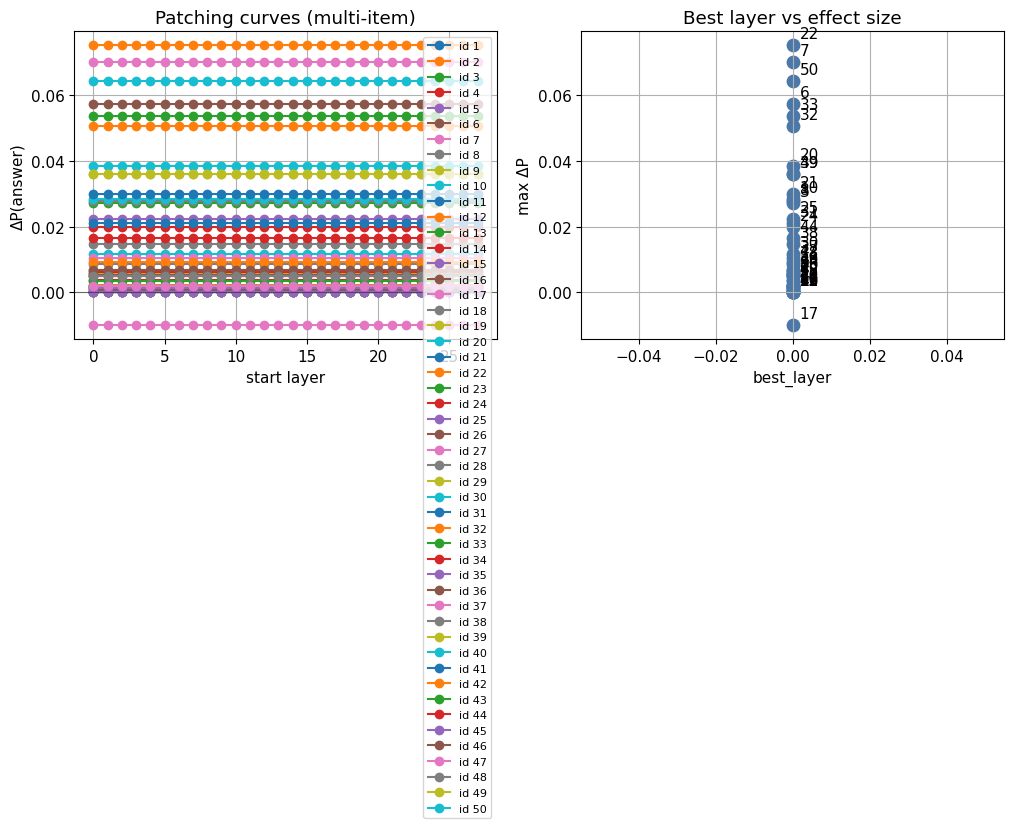

In [53]:
try:
    import pandas as pd
    df = pd.DataFrame(cmp_rows)
    display(df)
except Exception:
    df = None
    for r in cmp_rows:
        print(r)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: overlay ΔP curves
for item_id, curve in effect_curves.items():
    xs = sorted(int(k) for k in curve)
    ys = [curve[str(x)] for x in xs]
    axes[0].plot(xs, ys, marker="o", label=f"id {item_id}")
axes[0].axhline(0, color="k", lw=0.8, alpha=0.4)
axes[0].set_xlabel("start layer")
axes[0].set_ylabel("ΔP(answer)")
axes[0].set_title("Patching curves (multi-item)")
axes[0].legend(fontsize=8)

# right: best layer vs max effect
ids = [r["id"] for r in cmp_rows]
bests = [r["best_layer"] for r in cmp_rows]
maxd = [r["max_delta_p"] for r in cmp_rows]
axes[1].scatter(bests, maxd, s=80, c="#4C78A8")
for i, _id in enumerate(ids):
    axes[1].annotate(str(_id), (bests[i], maxd[i]), textcoords="offset points", xytext=(5, 5))
axes[1].set_xlabel("best_layer")
axes[1].set_ylabel("max ΔP")
axes[1].set_title("Best layer vs effect size")

plt.tight_layout()
fig.savefig(OUT["figures"] / "part6_compare_patching.png", dpi=150)
fig.savefig(OUT["comparison"] / "multi_item_patching.png", dpi=150)
plt.show()

### 6.3 Method comparison figure (this session’s shared item)

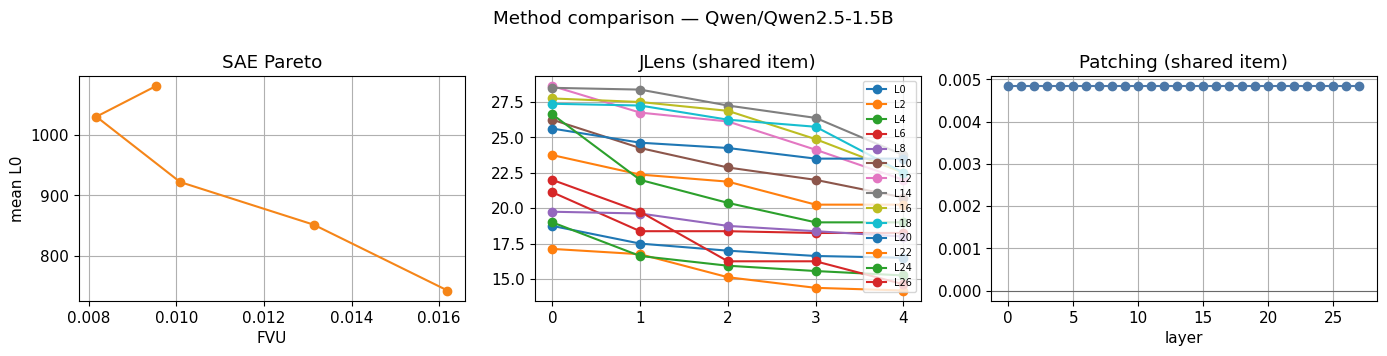

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# SAE FVU vs α from Part 2 sweep
if "rows" in dir() and rows:
    axes[0].plot([r["fvu"] for r in rows], [r["mean_l0"] for r in rows], marker="o", color="#F58518")
    axes[0].set_xlabel("FVU")
    axes[0].set_ylabel("mean L0")
    axes[0].set_title("SAE Pareto")
else:
    axes[0].text(0.5, 0.5, "run Part 2", ha="center")
    axes[0].set_title("SAE")

# JLens ranks
if "jlens_out" in dir():
    for layer, toks in jlens_out.top_tokens.items():
        axes[1].plot([t["logit"] for t in toks[:5]], marker="o", label=f"L{layer}")
    axes[1].legend(fontsize=7)
    axes[1].set_title("JLens (shared item)")
else:
    axes[1].text(0.5, 0.5, "run Part 3/5", ha="center")
    axes[1].set_title("JLens")

# Patching shared item
if "patch" in dir():
    xs = sorted(patch.scores)
    axes[2].plot(xs, [patch.scores[L] for L in xs], marker="o", color="#4C78A8")
    axes[2].axhline(0, color="k", lw=0.8, alpha=0.4)
    axes[2].set_title("Patching ΔM (shared item)")
    axes[2].set_xlabel("layer")
else:
    axes[2].text(0.5, 0.5, "run Part 4", ha="center")
    axes[2].set_title("Patching")

plt.suptitle(f"Method comparison — {model.name}")
plt.tight_layout()
fig.savefig(OUT["figures"] / "part6_methods_panel.png", dpi=150)
fig.savefig(OUT["comparison"] / "methods_panel.png", dpi=150)
plt.show()

### 6.4 Export JSON + figure index

In [55]:
import json
from datetime import datetime, timezone

export = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "model": model.name,
    "device": str(model.device),
    "shared_item": {
        "id": pair.get("id"),
        "answer_en": ANSWER,
        "answer_fa": ANSWER_FA,
        "prompt_en_preview": PROMPT_EN[:240],
        "prompt_fa_preview": PROMPT_FA[:240],
    },
    "sae": sae_summary if "sae_summary" in dir() else None,
    "jlens": jlens_summary if "jlens_summary" in dir() else None,
    "patching_shared": patch_summary if "patch_summary" in dir() else None,
    "multi_item_rows": cmp_rows,
    "effect_curves": effect_curves,
    "figures": {
        "figures_dir": str(OUT["figures"]),
        "comparison_dir": str(OUT["comparison"]),
    },
}

out_json = OUT["comparison"] / "full_pipeline_summary.json"
save_json(export, out_json)
print("Wrote", out_json)

# also a compact CSV-friendly dump if pandas worked
if df is not None:
    csv_path = OUT["comparison"] / "multi_item_summary.csv"
    df.to_csv(csv_path, index=False)
    print("Wrote", csv_path)

print(json.dumps({k: export[k] for k in ("model", "shared_item")}, indent=2, ensure_ascii=False)[:800])

Wrote /content/drive/MyDrive/multilingual_mech/output/comparison/full_pipeline_summary.json
Wrote /content/drive/MyDrive/multilingual_mech/output/comparison/multi_item_summary.csv
{
  "model": "Qwen/Qwen2.5-1.5B",
  "shared_item": {
    "id": "1",
    "answer_en": "Divan-e Hafez",
    "answer_fa": "دیوان حافظ",
    "prompt_en_preview": "Which poetic collection by Hafez is traditionally used in Iran for fal-e Hafez?\n\nA. Divan-e Saadi\nB. Bustan-e Hafez\nC. Divan-e Hafez\nD. Golestan-e Saadi\n\nAnswer:",
    "prompt_fa_preview": "کدام مجموعه شعری حافظ به‌طور سنتی در ایران برای فال حافظ استفاده می‌شود؟\n\nA. دیوان سعدی\nB. بوستان حافظ\nC. دیوان حافظ\nD. گلستان سعدی\n\nAnswer:"
  }
}


## Cleanup — drop heavy SAE / JLens tensors

Keeps **figures + JSON/CSV metrics**. Deletes activations, Jacobian fit/lens weights, duplicate SAE dumps, and optional extra SAE checkpoints. Set flags below before running.


In [ ]:
from pathlib import Path

# What to remove (True = delete)
DELETE_ACTS = True
DELETE_JLENS_FIT_CKPT = True
DELETE_JLENS_WEIGHTS = True          # qwen_lens.pt
DELETE_LEARNED_DICTS = True          # sae/l1_sweep/learned_dicts.pt
DELETE_EXTRA_SAE_CHECKPOINTS = True  # keep at most one tied_sae_*.pt
KEEP_SAE_CHECKPOINT = "none"         # "none" | "mid" | path basename e.g. "tied_sae_alpha_8.60e-04.pt"
DELETE_DUPLICATE_JLENS_PNGS = True   # PNGs under jlens/ if figures/ already has analysis plots
DRY_RUN = False                      # True → only print what would be deleted

removed: list[Path] = []


def _rm(path: Path) -> None:
    if not path.exists():
        return
    if DRY_RUN:
        print("DRY", path)
        removed.append(path)
        return
    path.unlink()
    removed.append(path)
    print("removed", path)


sae_dir = OUT["sae"]
jlens_dir = OUT["jlens"]
sweep_dir = sae_dir / "l1_sweep"

if DELETE_ACTS:
    for p in sae_dir.glob("acts_L*.pt"):
        _rm(p)

if DELETE_LEARNED_DICTS:
    _rm(sweep_dir / "learned_dicts.pt")

if DELETE_EXTRA_SAE_CHECKPOINTS and sweep_dir.is_dir():
    ckpts = sorted(sweep_dir.glob("tied_sae_alpha_*.pt"))
    keep: Path | None = None
    if KEEP_SAE_CHECKPOINT == "mid" and ckpts:
        keep = ckpts[len(ckpts) // 2]
    elif KEEP_SAE_CHECKPOINT not in ("mid", "none"):
        cand = sweep_dir / KEEP_SAE_CHECKPOINT
        keep = cand if cand.exists() else None
    # KEEP_SAE_CHECKPOINT == "none" → keep is None
    for p in ckpts:
        if keep is not None and p.resolve() == keep.resolve():
            print("keep SAE checkpoint:", p)
            continue
        _rm(p)

if DELETE_JLENS_FIT_CKPT:
    _rm(jlens_dir / "qwen_jlens_fit.ckpt")
    for p in jlens_dir.glob("*.ckpt"):
        _rm(p)

if DELETE_JLENS_WEIGHTS:
    _rm(jlens_dir / "qwen_lens.pt")
    for p in jlens_dir.glob("*_lens.pt"):
        _rm(p)

if DELETE_DUPLICATE_JLENS_PNGS:
    for p in jlens_dir.glob("*.png"):
        _rm(p)

print(f"done — {'would remove' if DRY_RUN else 'removed'} {len(removed)} file(s)")
print("kept metrics/figures under:", OUT["figures"], OUT["comparison"])
print("kept JSON under jlens (if any):", list(jlens_dir.glob("*.json")))
print("kept SAE metrics:", sweep_dir / "sweep_metrics.json", "exists=", (sweep_dir / "sweep_metrics.json").exists())
